# Generate Synthetic Training Data

This notebook contains the code to generate synthetic training data for the project, _i.e._, new PROTAC molecules generated from joining ligands from the curated data (via `Chem.molzip`).

Our plan here is to generate (at least) 1M new PROTAC molecules, which will be used to train the model in the next steps.

## Setup

In [7]:
import os
import sys
import json
from typing import List, Dict, Tuple, Union

import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.manifold import TSNE

from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem.rdchem import Mol
from rdkit.ML.Cluster import Butina
from rdkit.rdBase import BlockLogs

sys.path.append(os.path.join(os.getcwd(), '..', 'protac_splitter'))

from protac_splitter.data.generation import (
    generate_protacs,
    get_functional_group_at_attachment,
    get_functional_groups_distributions,
)
from protac_splitter.chemoinformatics import (
    canonize,
    canonize_smiles,
    canonize_smarts,
    remove_dummy_atoms,
)

In [8]:
data_dir = os.path.join(os.getcwd(), '..', 'data')

# mapped_protacs = pd.read_csv(os.path.join(data_dir, 'processed', 'mapped_protacs.csv'))
# manually_mapped_protacs = pd.read_csv(os.path.join(data_dir, 'processed', 'manually_mapped_protacs.csv'))
# protac_df = pd.concat([mapped_protacs, manually_mapped_protacs], ignore_index=True)

# # Drop duplicates on 'PROTAC SMILES' column, but keep the ones with
# # '(manually_mapped=True)' in the 'Notes' column
# protac_df = protac_df.drop_duplicates(subset='PROTAC SMILES', keep='last')

protac_df = pd.read_csv(os.path.join(data_dir, 'processed', 'mapped_protacs_with_functional_groups.csv'))

len(protac_df)

5670

In [9]:
filename_df_with_functional_groups = os.path.join(data_dir, 'processed', 'mapped_protacs_with_functional_groups.csv')
df_with_functional_groups = pd.read_csv(filename_df_with_functional_groups)
len(df_with_functional_groups)

5670

## Get Fingerprints and Embeddings

In [5]:
e3_list = df_with_functional_groups['E3 Binder SMILES with direction'].unique()
wh_list = df_with_functional_groups['POI Ligand SMILES with direction'].unique()
lk_list = df_with_functional_groups['Linker SMILES with direction'].unique()

In [6]:
morgan_fp_generator = Chem.rdFingerprintGenerator.GetMorganGenerator(
    radius=16,
    fpSize=1024,
    useBondTypes=True,
    includeChirality=True,
)

# Get the Numpy fingerprints of the ligands
e3_fp_np_list = [morgan_fp_generator.GetFingerprintAsNumPy(Chem.MolFromSmiles(smiles)) for smiles in e3_list]
wh_fp_np_list = [morgan_fp_generator.GetFingerprintAsNumPy(Chem.MolFromSmiles(smiles)) for smiles in wh_list]
lk_fp_np_list = [morgan_fp_generator.GetFingerprintAsNumPy(Chem.MolFromSmiles(smiles)) for smiles in lk_list]

# Get the fingerprints of the ligands
e3_fp_list = [morgan_fp_generator.GetFingerprint(Chem.MolFromSmiles(smiles)) for smiles in e3_list]
wh_fp_list = [morgan_fp_generator.GetFingerprint(Chem.MolFromSmiles(smiles)) for smiles in wh_list]
lk_fp_list = [morgan_fp_generator.GetFingerprint(Chem.MolFromSmiles(smiles)) for smiles in lk_list]

# Get the number of unique vectors in e3_fp_np_list
print(len(np.unique(e3_fp_np_list, axis=0)), len(e3_list))
print(len(np.unique(wh_fp_np_list, axis=0)), len(wh_list))
print(len(np.unique(lk_fp_np_list, axis=0)), len(lk_list))

253 253
883 883
1815 1927


In [7]:
import dash
from dash import dcc, html, Input, Output, no_update
import plotly.express as px
import pandas as pd
import base64
from io import BytesIO
from rdkit import Chem
from rdkit.Chem import Draw


e3_embedded = TSNE(
    n_components=2,
    learning_rate='auto',
    init='random',
    # perplexity=50,
    n_jobs=-1,
).fit_transform(np.array(e3_fp_np_list))

wh_embedded = TSNE(
    n_components=2,
    learning_rate='auto',
    init='random',
    # perplexity=3,
    n_jobs=-1,
).fit_transform(np.array(wh_fp_np_list))

lk_embedded = TSNE(
    n_components=2,
    learning_rate='auto',
    init='random',
    # perplexity=3,
    n_jobs=-1,
).fit_transform(np.array(lk_fp_np_list))

# Convert RDKit molecules to base64-encoded images
def mol_to_base64(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    img = Draw.MolToImage(mol, size=(300, 300))
    buffered = BytesIO()
    img.save(buffered, format="PNG")
    img_str = base64.b64encode(buffered.getvalue()).decode()
    return f"data:image/png;base64,{img_str}"


e3_df = pd.DataFrame(e3_embedded, columns=['x', 'y'])
e3_df['smiles'] = e3_list

# Add base64 images to DataFrame
e3_df['mol_img_base64'] = [mol_to_base64(smiles) for smiles in e3_list]

wh_df = pd.DataFrame(wh_embedded, columns=['x', 'y'])
wh_df['smiles'] = wh_list

# Add base64 images to DataFrame
wh_df['mol_img_base64'] = [mol_to_base64(smiles) for smiles in wh_list]

lk_df = pd.DataFrame(lk_embedded, columns=['x', 'y'])
lk_df['smiles'] = lk_list

# Add base64 images to DataFrame
lk_df['mol_img_base64'] = [mol_to_base64(smiles) for smiles in lk_list]

## Define the Clusters

In [8]:
from useful_rdkit_utils.split_utils import (
    taylor_butina_clustering,
    get_bemis_murcko_clusters,
    get_umap_clusters,
)

In [9]:
from rdkit.Chem.Scaffolds.MurckoScaffold import MurckoScaffoldSmiles
from sklearn.cluster import AgglomerativeClustering, KMeans

def get_scaffold(smi: Union[str, Mol]) -> str:
    """
    Generate the Bemis-Murcko scaffold for a given molecule.

    :param smi: A SMILES string or an RDKit molecule object representing the
                molecule for which to generate the scaffold.
    :return: A SMILES string representing the Bemis-Murcko scaffold of the input
             molecule. If the scaffold cannot be generated, the input SMILES
             string is returned.
    """
    scaffold = MurckoScaffoldSmiles(smi)
    if len(scaffold) == 0:
        scaffold = smi
    return scaffold


def get_umap_clusters_fp(fp_list: List[str], n_clusters: int = 7) -> np.ndarray:
    """
    Cluster a list of SMILES strings using the umap clustering algorithm.
    From Scaffold Splits Overestimate Virtual Screening Performance
    https://arxiv.org/abs/2406.00873



    :param fp_list: List of SMILES strings
    :param n_clusters: The number of clusters to use for clustering
    :return: Array of cluster labels corresponding to each SMILES string in the input list.
    """
    ac = AgglomerativeClustering(n_clusters=n_clusters)
    ac.fit_predict(np.stack(fp_list))
    return ac.labels_


def get_kmeans_clusters_fp(fp_list: List[str], n_clusters: int = 10) -> np.ndarray:
    """
    Cluster a list of SMILES strings using the KMeans clustering algorithm.

    :param fp_list: List of SMILES strings
    :param n_clusters: The number of clusters to use for clustering
    :return: Array of cluster labels corresponding to each SMILES string in the input list.
    """
    km = KMeans(n_clusters=n_clusters, n_init='auto', random_state=42, max_iter=1000)
    return km.fit_predict(np.stack(fp_list))

E3 Num clusters:   30, avg. size: 8.43, avg. size w.r.t. data size: 3.33% (x3: 10.00%)
WH Num clusters:  230, avg. size: 3.84, avg. size w.r.t. data size: 0.43% (x3: 1.30%)
LK Num clusters:  221, avg. size: 8.72, avg. size w.r.t. data size: 0.45% (x3: 1.36%)
  - E3 silhouette: -0.067
  - E3 davies_bouldin: 1.590
  - E3 calinski_harabasz: 3.300
  - E3 avg_cluster_size: 8.433
  - E3 avg_cluster_data_ratio: 0.033
  - E3 std_cluster_size: 18.759
  - E3 min_cluster_size: 1.000
  - E3 median_cluster_size: 2.000
  - E3 max_cluster_size: 95.000
  - E3 cluster_size_skewness: 3.563
  - E3 num_clusters: 30.000

  - POI silhouette: 0.054
  - POI davies_bouldin: 1.333
  - POI calinski_harabasz: 3.909
  - POI avg_cluster_size: 3.839
  - POI avg_cluster_data_ratio: 0.004
  - POI std_cluster_size: 5.003
  - POI min_cluster_size: 1.000
  - POI median_cluster_size: 2.000
  - POI max_cluster_size: 43.000
  - POI cluster_size_skewness: 3.691
  - POI num_clusters: 230.000

  - Linker silhouette: -0.039
  -

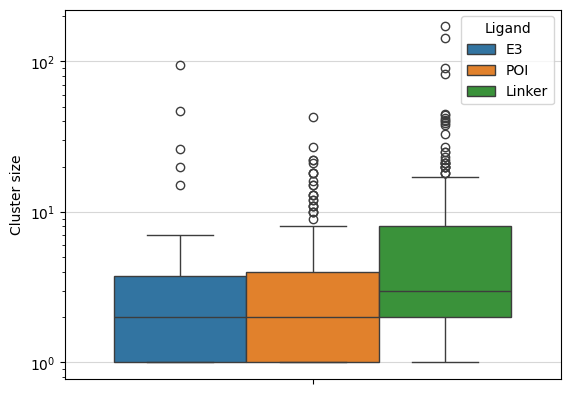

In [10]:
import seaborn as sns
from matplotlib import pyplot as plt
from scipy.stats import skew
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

def evaluate_clusters(X, clusters):
    """Compute clustering metrics and assess cluster size distribution."""
    
    unique_clusters = list(set(clusters))
    
    if len(unique_clusters) < 2:  # Avoid single-cluster issues
        return {
            "silhouette": -1,
            "davies_bouldin": float("inf"),
            "calinski_harabasz": -1,
            "avg_cluster_size": len(X),
            "avg_cluster_data_ratio": 1,
            "std_cluster_size": 0,
            "min_cluster_size": len(X),
            "median_cluster_size": len(X),
            "max_cluster_size": len(X),
            "cluster_size_skewness": 0,
            "num_clusters": 1,
        }

    # Compute standard clustering metrics
    silhouette = silhouette_score(X, clusters)
    davies_bouldin = davies_bouldin_score(X, clusters)
    calinski_harabasz = calinski_harabasz_score(X, clusters)

    # Compute cluster size statistics
    cluster_sizes = [len(np.where(clusters == i)[0]) for i in np.unique(clusters)]
    avg_cluster_size = np.mean(cluster_sizes)
    avg_cluster_data_ratio = avg_cluster_size / len(X)
    std_cluster_size = np.std(cluster_sizes)
    median_cluster_size = np.median(cluster_sizes)
    min_cluster_size = np.min(cluster_sizes)
    max_cluster_size = np.max(cluster_sizes)
    cluster_size_skewness = skew(cluster_sizes, nan_policy="omit")  # Indicates imbalance in cluster sizes

    return {
        "silhouette": silhouette,
        "davies_bouldin": davies_bouldin,
        "calinski_harabasz": calinski_harabasz,
        "avg_cluster_size": avg_cluster_size,
        "avg_cluster_data_ratio": avg_cluster_data_ratio,
        "std_cluster_size": std_cluster_size,
        "min_cluster_size": min_cluster_size,
        "median_cluster_size": median_cluster_size,
        "max_cluster_size": max_cluster_size,
        "cluster_size_skewness": cluster_size_skewness,
        "num_clusters": len(unique_clusters),
    }

e3_clusters = taylor_butina_clustering(e3_fp_list, cutoff=0.82) # 0.86 might work well in practice
wh_clusters = taylor_butina_clustering(wh_fp_list, cutoff=0.77) # 0.90 might work well in practice
lk_clusters = taylor_butina_clustering(lk_fp_list, cutoff=0.71) # 0.87 might work well in practice

# e3_clusters = get_umap_clusters_fp(e3_fp_np_list, n_clusters=34) # By looking at the metrics, good value: 34
# wh_clusters = get_umap_clusters_fp(wh_fp_np_list, n_clusters=29) # By looking at the metrics, good value: 29
# lk_clusters = get_umap_clusters_fp(lk_fp_np_list, n_clusters=29) # By looking at the metrics, good value: 29

# e3_clusters = get_kmeans_clusters_fp(e3_fp_np_list, n_clusters=8) # By looking at the metrics, good value: 8
# wh_clusters = get_kmeans_clusters_fp(wh_fp_np_list, n_clusters=15) # By looking at the metrics, good value: 15
# lk_clusters = get_kmeans_clusters_fp(lk_fp_np_list, n_clusters=15) # By looking at the metrics, good value: 15

# e3_clusters = get_bemis_murcko_clusters(e3_list)
# wh_clusters = get_bemis_murcko_clusters(wh_list)
# lk_clusters = get_bemis_murcko_clusters(lk_list)

# TODO: Is the attachment point affacting the scaffold generation?
# e3_clusters = get_bemis_murcko_clusters([Chem.MolToSmiles(remove_dummy_atoms(Chem.MolFromSmiles(s))) for s in e3_list])
# wh_clusters = get_bemis_murcko_clusters([Chem.MolToSmiles(remove_dummy_atoms(Chem.MolFromSmiles(s))) for s in wh_list])
# lk_clusters = get_bemis_murcko_clusters([Chem.MolToSmiles(remove_dummy_atoms(Chem.MolFromSmiles(s))) for s in lk_list])

e3_df['cluster'] = e3_clusters
wh_df['cluster'] = wh_clusters
lk_df['cluster'] = lk_clusters

assert len(e3_list) == len(e3_clusters)
assert len(wh_list) == len(wh_clusters)
assert len(lk_list) == len(lk_clusters)

e3_avg_size = len(e3_list) / len(np.unique(e3_clusters))
wh_avg_size = len(wh_list) / len(np.unique(wh_clusters))
lk_avg_size = len(lk_list) / len(np.unique(lk_clusters))

e3_sd_size = np.std([len(np.where(e3_clusters == i)[0]) for i in np.unique(e3_clusters)])
wh_sd_size = np.std([len(np.where(wh_clusters == i)[0]) for i in np.unique(wh_clusters)])
lk_sd_size = np.std([len(np.where(lk_clusters == i)[0]) for i in np.unique(lk_clusters)])

# Print the number of unique clusters
print(f"E3 Num clusters: {len(np.unique(e3_clusters)):4d}, avg. size: {e3_avg_size:>3.2f}, avg. size w.r.t. data size: {e3_avg_size / len(e3_list):>.2%} (x3: {3 * e3_avg_size / len(e3_list):>.2%})")
print(f"WH Num clusters: {len(np.unique(wh_clusters)):4d}, avg. size: {wh_avg_size:>3.2f}, avg. size w.r.t. data size: {wh_avg_size / len(wh_list):>.2%} (x3: {3 * wh_avg_size / len(wh_list):>.2%})")
print(f"LK Num clusters: {len(np.unique(lk_clusters)):4d}, avg. size: {lk_avg_size:>3.2f}, avg. size w.r.t. data size: {lk_avg_size / len(lk_list):>.2%} (x3: {3 * lk_avg_size / len(lk_list):>.2%})")

for X, clusters, name in [(e3_fp_np_list, e3_clusters, 'E3'), (wh_fp_np_list, wh_clusters, 'POI'), (lk_fp_np_list, lk_clusters, 'Linker')]:
    metrics = evaluate_clusters(X, clusters)
    # print(f"{name} Silhouette: {metrics['silhouette']:.3f}, Davies-Bouldin: {metrics['davies_bouldin']:.3f}, Calinski-Harabasz: {metrics['calinski_harabasz']:.3f}, Avg. cluster size: {metrics['avg_cluster_size']:.2f}, Std. cluster size: {metrics['std_cluster_size']:.2f}, Min. cluster size: {metrics['min_cluster_size']}, Max. cluster size: {metrics['max_cluster_size']}, Skewness: {metrics['cluster_size_skewness']:.2f}, Num. clusters: {metrics['num_clusters']}")
    for k, v in metrics.items():
        print(f"  - {name} {k}: {v:.3f}")
    print()

# Box plot the number of elements in each cluster using seaborn
e3_sizes = [len(np.where(e3_clusters == i)[0]) for i in np.unique(e3_clusters)]
wh_sizes = [len(np.where(wh_clusters == i)[0]) for i in np.unique(wh_clusters)]
lk_sizes = [len(np.where(lk_clusters == i)[0]) for i in np.unique(lk_clusters)]

df_to_plot = pd.DataFrame({
    'Ligand': ['E3'] * len(e3_sizes) + ['POI'] * len(wh_sizes) + ['Linker'] * len(lk_sizes),
    'Cluster size': e3_sizes + wh_sizes + lk_sizes,
})

sns.boxplot(data=df_to_plot, hue='Ligand', y='Cluster size')
# Set y-axis to log scale
plt.yscale('log')
plt.grid(axis='y', alpha=0.5)
plt.show()

Let's investigate how the threshold in Butina influences the clustering.

In [11]:
# Get a line plot of the matrics versus the threshold value of the taylor_butina_clustering function
def get_metrics_vs_threshold(fp_list, fp_np_list, max_threshold=0.98, step=0.01):
    thresholds = np.arange(0.5, max_threshold, step)
    metrics = np.array([list(evaluate_clusters(fp_np_list, taylor_butina_clustering(fp_list, cutoff=threshold)).values()) for threshold in thresholds])
    return thresholds, metrics

e3_thresholds, e3_metrics = get_metrics_vs_threshold(e3_fp_list, e3_fp_np_list)
wh_thresholds, wh_metrics = get_metrics_vs_threshold(wh_fp_list, wh_fp_np_list)
lk_thresholds, lk_metrics = get_metrics_vs_threshold(lk_fp_list, lk_fp_np_list)

Line plot threshold vs. metrics: is there a sharp change in the curve/plot at a specific threshold?

In [12]:
import plotly.graph_objects as go

layout = dict(
    hoversubplots="axis",
    title=dict(text="metrics vs. threshold"),
    hovermode="x",
    grid=dict(rows=1, columns=1),
)

data = [
    [
        go.Scatter(x=e3_thresholds, y=e3_metrics[:, 0], xaxis='x', yaxis='y', name='E3 Silhouette'),
        go.Scatter(x=e3_thresholds, y=e3_metrics[:, 1], xaxis='x', yaxis='y', name='E3 Davies-Bouldin'),
        go.Scatter(x=e3_thresholds, y=e3_metrics[:, 2], xaxis='x', yaxis='y', name='E3 Calinski-Harabasz'),
        go.Scatter(x=e3_thresholds, y=e3_metrics[:, 4], xaxis='x', yaxis='y', name='E3 Avg. Data Ratio'),
        go.Scatter(x=e3_thresholds, y=e3_metrics[:, 5] / max(e3_metrics[:, 5]), xaxis='x', yaxis='y', name='E3 STD'),
        go.Scatter(x=e3_thresholds, y=e3_metrics[:, 0] - e3_metrics[:, 1] + e3_metrics[:, 2] + e3_metrics[:, 4] + e3_metrics[:, 5] / max(e3_metrics[:, 5]), xaxis='x', yaxis='y', name='E3 Total'),
    ],
    [
        go.Scatter(x=wh_thresholds, y=wh_metrics[:, 0], xaxis='x', yaxis='y', name='WH Silhouette'),
        go.Scatter(x=wh_thresholds, y=wh_metrics[:, 1], xaxis='x', yaxis='y', name='WH Davies-Bouldin'),
        go.Scatter(x=wh_thresholds, y=wh_metrics[:, 2], xaxis='x', yaxis='y', name='WH Calinski-Harabasz'),
        go.Scatter(x=wh_thresholds, y=wh_metrics[:, 4], xaxis='x', yaxis='y', name='WH Avg. Data Ratio'),
        go.Scatter(x=wh_thresholds, y=wh_metrics[:, 5] / max(wh_metrics[:, 5]), xaxis='x', yaxis='y', name='WH STD'),
        go.Scatter(x=wh_thresholds, y=wh_metrics[:, 0] - wh_metrics[:, 1] + wh_metrics[:, 2] + wh_metrics[:, 4] + wh_metrics[:, 5] / max(wh_metrics[:, 5]), xaxis='x', yaxis='y', name='WH Total'),
    ],
    [
        go.Scatter(x=lk_thresholds, y=lk_metrics[:, 0], xaxis='x', yaxis='y', name='LK Silhouette'),
        go.Scatter(x=lk_thresholds, y=lk_metrics[:, 1], xaxis='x', yaxis='y', name='LK Davies-Bouldin'),
        go.Scatter(x=lk_thresholds, y=lk_metrics[:, 2], xaxis='x', yaxis='y', name='LK Calinski-Harabasz'),
        go.Scatter(x=lk_thresholds, y=lk_metrics[:, 4], xaxis='x', yaxis='y', name='LK Avg. Data Ratio'),
        go.Scatter(x=lk_thresholds, y=lk_metrics[:, 5] / max(lk_metrics[:, 5]), xaxis='x', yaxis='y', name='LK STD'),
        go.Scatter(x=lk_thresholds, y=lk_metrics[:, 0] - lk_metrics[:, 1] + lk_metrics[:, 2] + lk_metrics[:, 4] + lk_metrics[:, 5] / max(lk_metrics[:, 5]), xaxis='x', yaxis='y', name='LK Total'),
    ],
]

for d in data:
    fig = go.Figure(data=d, layout=layout)
    fig.show()

Based on the above, we can cluster using the following cut-offs:

In [13]:
e3_clusters = taylor_butina_clustering(e3_fp_list, cutoff=0.82) # 0.86 might work well in practice
wh_clusters = taylor_butina_clustering(wh_fp_list, cutoff=0.77) # 0.77 might work well in practice
lk_clusters = taylor_butina_clustering(lk_fp_list, cutoff=0.71) # 0.87 might work well in practice

We can also collect clustering metrics with other clustering algorithms, such as K-means, when varying the number of clusters.

In [14]:
def get_metrics_vs_n_clusters(fp_np_list, max_clusters=20):
    n_clusters = np.arange(2, max_clusters, 1)
    metrics = np.array([list(evaluate_clusters(fp_np_list, get_kmeans_clusters_fp(fp_np_list, n_clusters=n)).values()) for n in n_clusters])
    # metrics = np.array([list(evaluate_clusters(fp_np_list, get_umap_clusters_fp(fp_np_list, n_clusters=n)).values()) for n in n_clusters])
    return n_clusters, metrics

# e3_n_clusters, e3_metrics = get_metrics_vs_n_clusters(e3_fp_np_list)
# wh_n_clusters, wh_metrics = get_metrics_vs_n_clusters(wh_fp_np_list)
# lk_n_clusters, lk_metrics = get_metrics_vs_n_clusters(lk_fp_np_list)

We can indeed plot the number of clusters vs. metrics, and see if there is a sharp change in the curve/plot at a specific number of clusters.

In [15]:
# layout = dict(
#     hoversubplots="axis",
#     title=dict(text="E3 n_clusters vs. metrics"),
#     hovermode="x",
#     grid=dict(rows=1, columns=1),
# )

# data = [
#     go.Scatter(x=e3_n_clusters, y=e3_metrics[:, 0], xaxis='x', yaxis='y', name='E3 Silhouette'),
#     go.Scatter(x=e3_n_clusters, y=e3_metrics[:, 1], xaxis='x', yaxis='y', name='E3 Davies-Bouldin'),
#     go.Scatter(x=e3_n_clusters, y=e3_metrics[:, 2], xaxis='x', yaxis='y', name='E3 Calinski-Harabasz'),
# ]

# fig = go.Figure(data=data, layout=layout)

# fig.show()

# layout = dict(
#     hoversubplots="axis",
#     title=dict(text="WH n_clusters vs. n_metrics"),
#     hovermode="x",
#     grid=dict(rows=1, columns=1),
# )

# data = [
#     go.Scatter(x=wh_n_clusters, y=wh_metrics[:, 0], xaxis='x', yaxis='y', name='WH Silhouette'),
#     go.Scatter(x=wh_n_clusters, y=wh_metrics[:, 1], xaxis='x', yaxis='y', name='WH Davies-Bouldin'),
#     go.Scatter(x=wh_n_clusters, y=wh_metrics[:, 2], xaxis='x', yaxis='y', name='WH Calinski-Harabasz'),
# ]

# fig = go.Figure(data=data, layout=layout)

# fig.show()

# layout = dict(
#     hoversubplots="axis",
#     title=dict(text="Linker n_clusters vs. n_metrics"),
#     hovermode="x",
#     grid=dict(rows=1, columns=1),
# )

# data = [
#     go.Scatter(x=lk_n_clusters, y=wh_metrics[:, 0], xaxis='x', yaxis='y', name='LK Silhouette'),
#     go.Scatter(x=lk_n_clusters, y=wh_metrics[:, 1], xaxis='x', yaxis='y', name='LK Davies-Bouldin'),
#     go.Scatter(x=lk_n_clusters, y=wh_metrics[:, 2], xaxis='x', yaxis='y', name='LK Calinski-Harabasz'),
# ]

# fig = go.Figure(data=data, layout=layout)

# fig.show()

The following is a short snippet for making a silhouette plot. Not very insightful, though. Left for future reference.

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_samples, silhouette_score


def tanimoto_distance(A: np.ndarray, B: np.ndarray) -> float:
    """
    Compute the Tanimoto distance between two numpy arrays.

    Args:
        A (np.ndarray): First fingerprint vector.
        B (np.ndarray): Second fingerprint vector.

    Returns:
        float: Tanimoto distance (0 = identical, 1 = completely dissimilar).
    """
    dot_product = np.dot(A, B)
    norm_A = np.sum(A)
    norm_B = np.sum(B)
    
    if norm_A + norm_B - dot_product == 0:
        return 0.0  # To avoid division by zero if both are empty vectors
    
    tanimoto_sim = dot_product / (norm_A + norm_B - dot_product)
    return 1 - tanimoto_sim  # Convert similarity to distance


def plot_silhouette(X, labels, title="Silhouette Plot"):
    """
    Generate a silhouette plot for the given clustered data.

    Args:
        X (numpy.ndarray): Feature matrix (e.g., fingerprints or embeddings).
        labels (list or np.ndarray): Cluster labels for each data point.
        title (str): Title for the plot.
    """
    # Compute silhouette scores for each point
    silhouette_vals = silhouette_samples(X, labels, metric=tanimoto_distance)
    avg_score = silhouette_score(X, labels, metric=tanimoto_distance)

    # Sort silhouette values within each cluster
    unique_labels = np.unique(labels)
    y_lower = 10  # Baseline for plotting

    plt.figure(figsize=(8, 6))
    
    for i, label in enumerate(unique_labels):
        cluster_silhouette_vals = silhouette_vals[labels == label]
        cluster_silhouette_vals.sort()
        size_cluster = cluster_silhouette_vals.shape[0]
        y_upper = y_lower + size_cluster

        plt.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_vals, alpha=0.7, label=f"Cluster {label}")
        
        y_lower = y_upper + 10  # Add some space between clusters

    plt.axvline(avg_score, color="red", linestyle="--", label=f"Avg silhouette: {avg_score:.2f}")

    plt.xlabel("Silhouette Coefficient")
    plt.ylabel("Cluster Members")
    plt.title(title)
    # plt.legend()
    plt.show()

    print(f"Average Silhouette Score: {avg_score:.3f}")

# # Example usage:
# plot_silhouette(e3_fp_list, e3_clusters, title="E3 Clusters Silhouette Plot")
# plot_silhouette(wh_fp_list, wh_clusters, title="WH Clusters Silhouette Plot")
# plot_silhouette(lk_fp_list, lk_clusters, title="LK Clusters Silhouette Plot")

## Clusters Plotting (with interactive plots)

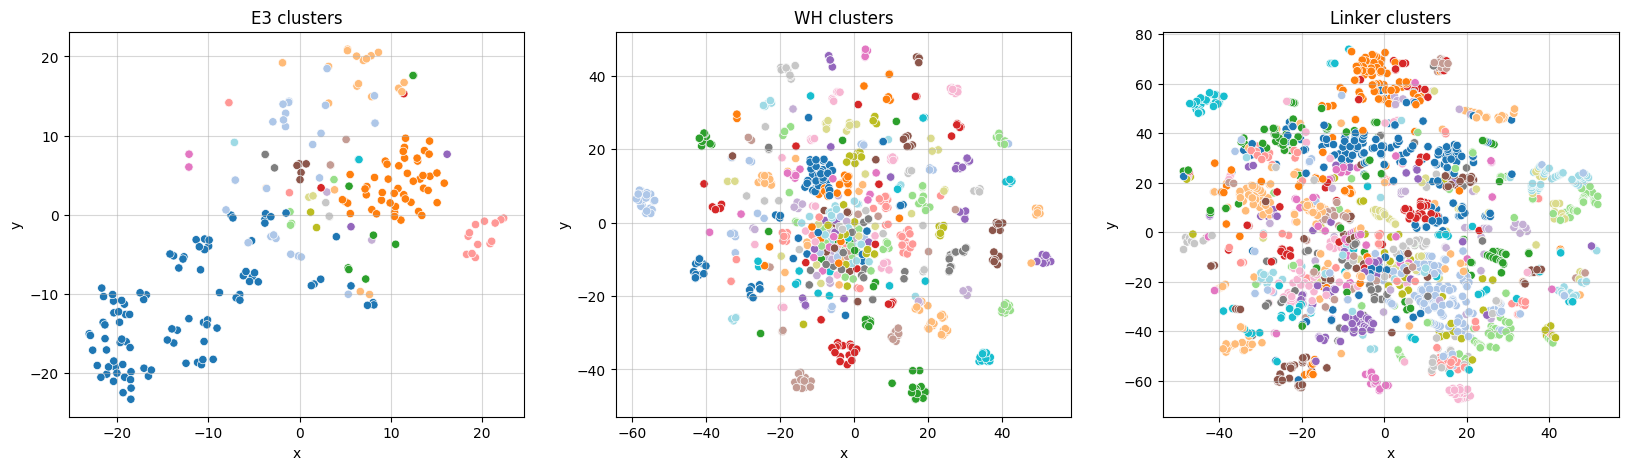

In [17]:
titles = ['E3 clusters', 'WH clusters', 'Linker clusters']

# Have the three plots in a single figure, horizontally
fig, axs = plt.subplots(1, 3, figsize=(20, 5))

for i, title in enumerate(titles):
    if title == 'E3 clusters':
        df_to_plot = e3_df.copy()
    elif title == 'WH clusters':
        df_to_plot = wh_df.copy()
    else:
        df_to_plot = lk_df.copy()

    # Use seaborn to plot the clusters
    sns.scatterplot(data=df_to_plot, x='x', y='y', hue='cluster', palette='tab20', legend=False, ax=axs[i])
    axs[i].set_title(title)
    axs[i].grid(alpha=0.5)
    
plt.show()

We can use plotly to visualize the molecules in the clusters.

In [ ]:
title = 'E3 clusters'
# title = 'WH clusters'
# title = 'Linker clusters'

if title == 'E3 clusters':
    df_to_plot = e3_df.copy()
elif title == 'WH clusters':
    df_to_plot = wh_df.copy()
else:
    df_to_plot = lk_df.copy()

# df_to_plot['cluster'] = e3_butina_clusters

df_to_plot['cluster'] = df_to_plot['cluster'].astype(str) # Comment out for gradient coloring

fig = px.scatter(
    df_to_plot,
    x='x',
    y='y',
    color='cluster',
    custom_data=['mol_img_base64'],  # Store base64 image data
    title=title,
)

# Disable default hover info
fig.update_traces(hoverinfo="none", hovertemplate=None)

fig.update_layout(
    width=700,  # Set the figure width (adjust as needed)
    height=700,  # Set the figure height (same as width for square shape)
    autosize=False,  # Prevent automatic resizing
    xaxis=dict(scaleanchor="y")  # Keep x and y scales equal
)

# Initialize Dash app
app = dash.Dash(__name__)

# Define layout
app.layout = html.Div([
    dcc.Graph(id="graph", figure=fig, clear_on_unhover=True),
    dcc.Tooltip(id="graph-tooltip")
])

# Callback for hover-based tooltip
@app.callback(
    Output("graph-tooltip", "show"),
    Output("graph-tooltip", "bbox"),
    Output("graph-tooltip", "children"),
    Input("graph", "hoverData")
)
def display_hover(hoverData):
    if hoverData is None:
        return False, no_update, no_update
    
    # print(hoverData)

    # Get index of hovered point
    point_index = hoverData["points"][0]["pointIndex"]

    # Get base64 image, coordinates, and cluster
    img_src = df_to_plot.iloc[point_index]['mol_img_base64']
    x_coord = df_to_plot.iloc[point_index]['x']
    y_coord = df_to_plot.iloc[point_index]['y']
    cluster = df_to_plot.iloc[point_index]['cluster']
    num_clusters = len(df_to_plot[df_to_plot['cluster'] == cluster])

    # Create tooltip content
    children = html.Div([
        # html.P(f"x: {x_coord:.2f}, y: {y_coord:.2f}", style={"margin": "5px 0", "font-size": "14px"}),
        html.P(f"Cluster: {cluster}", style={"margin": "0", "font-weight": "bold", "font-size": "14px"}),
        html.P(f"#Elems in cluster: {num_clusters}", style={"margin": "0", "font-weight": "bold", "font-size": "14px"}),
        html.Img(src=img_src, style={"width": "200px", "height": "200px"}),
    ], style={'width': '180px', 'text-align': 'center', 'white-space': 'normal'})

    # Get bounding box of hovered point
    bbox = hoverData["points"][0]["bbox"]

    return True, bbox, children

# Run app
if __name__ == "__main__":
    app.run_server(debug=True)

## Optuna Clustering (Not Used)

In [19]:
import optuna
from scipy.stats import skew
from optuna.samplers import TPESampler, GridSampler
from sklearn.cluster import DBSCAN, AgglomerativeClustering, KMeans

def evaluate_clusters(X, clusters):
    """Compute clustering metrics and assess cluster size distribution."""
    
    unique_clusters = list(set(clusters))
    
    if len(unique_clusters) < 2:  # Avoid single-cluster issues
        return {
            "silhouette": -1,
            "davies_bouldin": float("inf"),
            "calinski_harabasz": -1,
            "avg_cluster_size": len(X),
            "std_cluster_size": 0,
            "min_cluster_size": len(X),
            "max_cluster_size": len(X),
            "cluster_size_skewness": 0,
            "num_clusters": 1,
        }

    # Compute standard clustering metrics
    silhouette = silhouette_score(X, clusters)
    davies_bouldin = davies_bouldin_score(X, clusters)
    calinski_harabasz = calinski_harabasz_score(X, clusters)

    # Compute cluster size statistics
    cluster_sizes = [len(np.where(clusters == i)[0]) for i in np.unique(clusters)]
    avg_cluster_size = np.mean(cluster_sizes)
    std_cluster_size = np.std(cluster_sizes)
    min_cluster_size = np.min(cluster_sizes)
    max_cluster_size = np.max(cluster_sizes)
    cluster_size_skewness = skew(cluster_sizes, nan_policy="omit")  # Indicates imbalance in cluster sizes

    return {
        "silhouette": silhouette,
        "davies_bouldin": davies_bouldin,
        "calinski_harabasz": calinski_harabasz,
        "avg_cluster_size": avg_cluster_size,
        "std_cluster_size": std_cluster_size,
        "min_cluster_size": min_cluster_size,
        "max_cluster_size": max_cluster_size,
        "cluster_size_skewness": cluster_size_skewness,
        "num_clusters": len(unique_clusters),
    }


def kmeans_wrapper(trial, X):
    """Wrapper for K-Means clustering with hyperparameter tuning.
    
    Args:
        trial (optuna.Trial): The trial object for hyperparameter search.
        X (numpy.ndarray): Input feature vectors (e.g., Morgan fingerprints).
    
    Returns:
        np.ndarray: Cluster labels.
    """

    # Hyperparameter search space
    n_clusters = trial.suggest_int("n_clusters", 2, min(100, len(X) // 2))  # Limit to half the dataset
    init_method = trial.suggest_categorical("init", ["k-means++", "random"])
    max_iter = trial.suggest_int("max_iter", 100, 500, step=50)  # Convergence speed control
    tol = trial.suggest_float("tol", 1e-6, 1e-2, log=True)  # Precision tolerance

    try:
        model = KMeans(
            n_clusters=n_clusters,
            init=init_method,
            max_iter=max_iter,
            tol=tol,
            random_state=42
        )
    except ValueError as e:
        # Print the error message and raise Optuna's exception
        print(f"Error: {e}")
        raise optuna.exceptions.TrialPruned

    return model.fit_predict(X)


def taylor_butina_wrapper(trial, X):
    """Wrapper for Taylor-Butina clustering with hyperparameter tuning.
    
    Args:
        trial (optuna.Trial): The trial object for hyperparameter search.
        X (list): List of RDKit Morgan fingerprints.
    
    Returns:
        np.ndarray: Cluster labels.
    """

    # Hyperparameter search space
    cutoff = trial.suggest_float("cutoff", 0.2, 0.99)  # Tanimoto similarity threshold

    try:
        clusters = taylor_butina_clustering(X, cutoff)
    except ValueError as e:
        # Print the error message and raise Optuna's exception
        print(f"Error: {e}")
        raise optuna.exceptions.TrialPruned
    
    if len(np.unique(clusters)) >= len(X):
        raise optuna.exceptions.TrialPruned  # Avoid singletons
    
    return clusters


def agglomerative_wrapper(trial, X):
    """Wrapper for Agglomerative clustering with hyperparameter tuning.
    
    Args:
        trial (optuna.Trial): The trial object for hyperparameter search.
        X (numpy.ndarray): Input feature vectors (e.g., Morgan fingerprints).
    
    Returns:
        np.ndarray: Cluster labels.
    """

    # Hyperparameter search space
    n_clusters = trial.suggest_int("n_clusters", 2, min(100, len(X) // 2))
    linkage = trial.suggest_categorical("linkage", ["ward", "complete", "average", "single"])
    affinity = trial.suggest_categorical("affinity", ["euclidean", "l1", "l2", "manhattan", "cosine"])

    try:
        model = AgglomerativeClustering(
            n_clusters=n_clusters,
            linkage=linkage,
            metric=affinity
        )
    except ValueError as e:
        # Print the error message and raise Optuna's exception
        print(f"Error: {e}")
        raise optuna.exceptions.TrialPruned

    return model.fit_predict(X)


def dbscan_wrapper(trial, X):
    """Wrapper for DBSCAN clustering with hyperparameter tuning.
    
    Args:
        trial (optuna.Trial): The trial object for hyperparameter search.
        X (numpy.ndarray): Input feature vectors (e.g., Morgan fingerprints).
    
    Returns:
        np.ndarray: Cluster labels.
    """

    # Hyperparameter search space
    eps = trial.suggest_float("eps", 0.1, 5.0)  # Neighborhood radius
    min_samples = trial.suggest_int("min_samples", 2, 50)  # Minimum points per cluster
    metric = trial.suggest_categorical("metric", ["euclidean", "manhattan", "cosine"])  # Distance metric

    try:
        model = DBSCAN(
            eps=eps,
            min_samples=min_samples,
            metric=metric
        )
    except ValueError as e:
        # Print the error message and raise Optuna's exception
        print(f"Error: {e}")
        raise optuna.exceptions.TrialPruned

    return model.fit_predict(X)



def evaluate_objective(metrics, X, target_cluster_size_ratio=0.1):
    """Compute a weighted objective score based on multiple clustering evaluation metrics."""
    
    if metrics is None:
        return float("-inf")
    
    if metrics["num_clusters"] < 2 or metrics["num_clusters"] >= len(X):
        return float("-inf")

    if metrics["avg_cluster_size"] < 1:
        return float("-inf")

    # Compute expected cluster size based on input percentage
    expected_size = target_cluster_size_ratio * len(X)

    # Compute penalties for deviations from expected cluster sizes
    cluster_size_penalty = abs(metrics["avg_cluster_size"] - expected_size) / expected_size
    # cluster_size_penalty = np.sqrt((metrics["avg_cluster_size"] - expected_size) ** 2)

    # Weights for balancing the optimization criteria
    alpha = 0.9  # Silhouette weight
    beta = 0.9  # Davies–Bouldin weight
    gamma = 0.9  # Calinski–Harabasz weight
    epsilon = 1.0  # Cluster size penalty (deviation from expected)
    delta = 0.1  # Cluster size std dev penalty
    zeta = 0.1  # Skewness penalty (to avoid long-tailed distributions)
    eta = 0.2  # Min/max cluster size variation penalty

    # Define a sigmoid function to squash the metrics
    sigmoid = lambda x: 1 / (1 + np.exp(-x))

    # Compute the final optimization score
    score = (
        alpha * sigmoid(metrics["silhouette"])
        - beta * sigmoid(metrics["davies_bouldin"])
        + gamma * sigmoid(metrics["calinski_harabasz"])
        - epsilon * cluster_size_penalty
        - delta * metrics["std_cluster_size"]
        - zeta * abs(metrics["cluster_size_skewness"])  # Penalize highly skewed cluster sizes
        - eta * (metrics["max_cluster_size"] - metrics["min_cluster_size"]) / expected_size  # Penalize too much spread
    )

    return score


def objective(trial, method, X, target_cluster_size_ratio=0.1):
    """Generalized Optuna objective function for clustering optimization.
    
    Args:
        trial (optuna.Trial): The trial object for hyperparameter optimization.
        method (str): Clustering algorithm name (e.g., "kmeans", "agglomerative", "dbscan", "taylor_butina").
        X (numpy.ndarray or list): Input data (e.g., Morgan fingerprints).
        target_cluster_size_ratio (float, optional): Ideal average cluster size as a fraction of total data.
        
    Returns:
        float: Computed optimization score.
    """

    # Select the appropriate clustering function
    if method == "kmeans":
        clusters = kmeans_wrapper(trial, X)
    elif method == "agglomerative":
        clusters = agglomerative_wrapper(trial, X)
    elif method == "dbscan":
        clusters = dbscan_wrapper(trial, X)
    elif method == "taylor_butina":
        clusters = taylor_butina_wrapper(trial, X)
    else:
        raise ValueError(f"Unknown clustering method: {method}")
    
    if clusters is None:
        return float("-inf")

    # Compute clustering evaluation metrics
    metrics = evaluate_clusters(X, clusters)
    
    # Update the trial object with the computed metrics
    if metrics is not None:
        for key, value in metrics.items():
            trial.set_user_attr(key, value)

    trial.set_user_attr("clusters", clusters)

    # Compute the final objective score
    return evaluate_objective(metrics, X, target_cluster_size_ratio)


def optimize_clustering(X, method, n_trials=100, target_cluster_size_ratio=0.1, return_clusters: bool = False):
    """Optimize clustering hyperparameters using Optuna.
    
    Args:
        X (numpy.ndarray or list): Input data (e.g., Morgan fingerprints).
        method (str): Clustering algorithm name (e.g., "kmeans", "agglomerative", "dbscan", "taylor_butina").
        n_trials (int): Number of hyperparameter optimization trials.
        target_cluster_size_ratio (float, optional): Ideal average cluster size as a fraction of total data.
        
    Returns:
        optuna.study.Study: Optuna study object with optimization results.
    """

    # Create an Optuna study object
    if method == "taylor_butina":
        # Define a search space sampler for Taylor-Butina clustering
        lower_cutoff = 0.4
        step = (1 - lower_cutoff) / n_trials
        search_space = {"cutoff": [lower_cutoff + i * step for i in range(n_trials)]}
        sampler = GridSampler(search_space, seed=42)
    else:
        sampler = TPESampler(seed=42)  # Make the sampler behave in a deterministic way.
    study = optuna.create_study(direction="maximize", sampler=sampler)

    # Define the objective function with the specified clustering method
    objective_fn = lambda trial: objective(trial, method, X, target_cluster_size_ratio)

    # Run the optimization trials
    study.optimize(objective_fn, n_trials=n_trials)
    
    for k, v in study.best_trial.user_attrs.items():
        print(f"- {k}: {v}")

    if return_clusters:
        # Get the best hyperparameters and return the cluster labels
        best_trial = study.best_trial
        if method == "kmeans":
            clusters = kmeans_wrapper(best_trial, X)
        elif method == "agglomerative":
            clusters = agglomerative_wrapper(best_trial, X)
        elif method == "dbscan":
            clusters = dbscan_wrapper(best_trial, X)
        elif method == "taylor_butina":
            clusters = taylor_butina_wrapper(best_trial, X)
        else:
            raise ValueError(f"Unknown clustering method: {method}")

        return study, clusters

    return study


# # Optimize K-Means clustering for E3 ligands
# # e3_kmeans_clusters = optimize_clustering(e3_fp_np_list, "kmeans", n_trials=50, target_cluster_size_ratio=0.05, return_clusters=True)
# # e3_agglo_clusters = optimize_clustering(e3_fp_np_list, "agglomerative", n_trials=50, target_cluster_size_ratio=0.05, return_clusters=True)
# # e3_dbscan_clusters = optimize_clustering(e3_fp_np_list, "dbscan", n_trials=50, target_cluster_size_ratio=0.05, return_clusters=True)
# e3_study, e3_butina_clusters = optimize_clustering(e3_fp_list, "taylor_butina", n_trials=50, target_cluster_size_ratio=0.05, return_clusters=True)
# wh_study, wh_butina_clusters = optimize_clustering(wh_fp_list, "taylor_butina", n_trials=50, target_cluster_size_ratio=0.05, return_clusters=True)
# lk_study, lk_butina_clusters = optimize_clustering(lk_fp_list, "taylor_butina", n_trials=50, target_cluster_size_ratio=0.05, return_clusters=True)

# # Box plot the number of elements in each cluster using seaborn
# e3_sizes = [len(np.where(e3_butina_clusters == i)[0]) for i in np.unique(e3_butina_clusters)]
# wh_sizes = [len(np.where(wh_butina_clusters == i)[0]) for i in np.unique(wh_butina_clusters)]
# lk_sizes = [len(np.where(lk_butina_clusters == i)[0]) for i in np.unique(lk_butina_clusters)]

# df_to_plot = pd.DataFrame({
#     'Ligand': ['E3'] * len(e3_sizes) + ['POI'] * len(wh_sizes) + ['Linker'] * len(lk_sizes),
#     'Cluster size': e3_sizes + wh_sizes + lk_sizes,
# })

# sns.boxplot(data=df_to_plot, hue='Ligand', y='Cluster size')
# # Set y-axis to log scale
# # plt.yscale('log')
# plt.grid(axis='y', alpha=0.5)
# plt.show()

# print(f"E3 best cutoff: {e3_study.best_params['cutoff']}")
# print(f"WH best cutoff: {wh_study.best_params['cutoff']}")
# print(f"LK best cutoff: {lk_study.best_params['cutoff']}")

## Divide the Clusters in Seen/Unseen

Divide the clusters into two categories: isolate $N$ clusters (_unseen_) to use for the validation/test sets.

For each ligand type, _i.e._, E3, linker, and WH, we will have:

- Unseen clusters: the SMILES associated to them cover around 10% of all available SMILES, used for validation/test.
- Seen clusters: the SMILES associated to them cover around 90% of all available SMILES, used for training.

In order to select them, we can use the following strategy:

1. For each ligand type, sort the clusters by how far they are from the average number of SMILES per cluster.
2. Select the first $N$ clusters, such that the sum of the cluster sizes is around 10% of all available SMILES.
3. The remaining clusters will be used for training.

E3: Avg. Cluster Size: 8.43 (3.33%)
WH: Avg. Cluster Size: 3.84 (0.43%)
LK: Avg. Cluster Size: 8.72 (0.45%)
--------------------------------------------------------------------------------
Number of E3 clusters:   11 unseen,   19 seen
Number of WH clusters:   40 unseen,  190 seen
Number of LK clusters:   40 unseen,  181 seen
--------------------------------------------------------------------------------
Number of unseen E3 ligands:   36 (14.23%)
Number of unseen WH ligands:  138 (15.63%)
Number of unseen LK ligands:  300 (15.57%)
--------------------------------------------------------------------------------


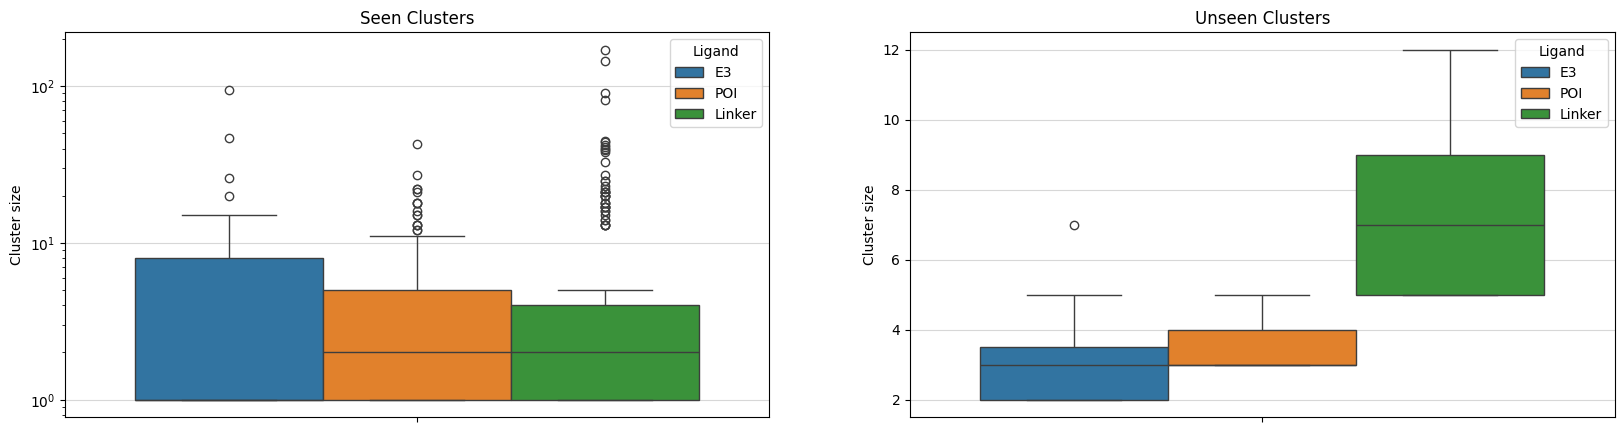

In [20]:
from collections import defaultdict

e3_smiles2cluster = {s: c for c, s in zip(e3_clusters, e3_list)}
wh_smiles2cluster = {s: c for c, s in zip(wh_clusters, wh_list)}
lk_smiles2cluster = {s: c for c, s in zip(lk_clusters, lk_list)}

e3_cluster2smiles = defaultdict(list)
wh_cluster2smiles = defaultdict(list)
lk_cluster2smiles = defaultdict(list)

e3_cluster2size = defaultdict(lambda: 0)
wh_cluster2size = defaultdict(lambda: 0)
lk_cluster2size = defaultdict(lambda: 0)

for s, c in e3_smiles2cluster.items():
    e3_cluster2smiles[c].append(s)
    e3_cluster2size[c] += 1

for s, c in wh_smiles2cluster.items():
    wh_cluster2smiles[c].append(s)
    wh_cluster2size[c] += 1

for s, c in lk_smiles2cluster.items():
    lk_cluster2smiles[c].append(s)
    lk_cluster2size[c] += 1

# For each ligand type, get the average cluster size
e3_avg_cluster_size = np.mean(list(e3_cluster2size.values()))
wh_avg_cluster_size = np.mean(list(wh_cluster2size.values()))
lk_avg_cluster_size = np.mean(list(lk_cluster2size.values()))

print(f"E3: Avg. Cluster Size: {e3_avg_cluster_size:.2f} ({e3_avg_cluster_size / len(e3_list):.2%})")
print(f"WH: Avg. Cluster Size: {wh_avg_cluster_size:.2f} ({wh_avg_cluster_size / len(wh_list):.2%})")
print(f"LK: Avg. Cluster Size: {lk_avg_cluster_size:.2f} ({lk_avg_cluster_size / len(lk_list):.2%})")

# For each ligand type, get the cluster with the size closest to the average
e3_closest_cluster = min(e3_cluster2size, key=lambda c: abs(e3_cluster2size[c] - e3_avg_cluster_size))
wh_closest_cluster = min(wh_cluster2size, key=lambda c: abs(wh_cluster2size[c] - wh_avg_cluster_size))
lk_closest_cluster = min(lk_cluster2size, key=lambda c: abs(lk_cluster2size[c] - lk_avg_cluster_size))

# Get the top-3 closest clusters to the average size
e3_num_isolated_clusters = 11
wh_num_isolated_clusters = 40
lk_num_isolated_clusters = 40
e3_closest_clusters = sorted(e3_cluster2size, key=lambda c: abs(e3_cluster2size[c] - e3_avg_cluster_size))[:e3_num_isolated_clusters]
wh_closest_clusters = sorted(wh_cluster2size, key=lambda c: abs(wh_cluster2size[c] - wh_avg_cluster_size))[:wh_num_isolated_clusters]
lk_closest_clusters = sorted(lk_cluster2size, key=lambda c: abs(lk_cluster2size[c] - lk_avg_cluster_size))[:lk_num_isolated_clusters]

e3_unseen_clusters = e3_closest_clusters
wh_unseen_clusters = wh_closest_clusters
lk_unseen_clusters = lk_closest_clusters

# By "seen" we mean that the clusters are used in the training set (the rest of the clusters)
e3_seen_clusters = [c for c in set(e3_clusters) if c not in e3_unseen_clusters]
wh_seen_clusters = [c for c in set(wh_clusters) if c not in wh_unseen_clusters]
lk_seen_clusters = [c for c in set(lk_clusters) if c not in lk_unseen_clusters]

# Print their sizes
print("-" * 80)
print(f"Number of E3 clusters: {len(e3_unseen_clusters):>4d} unseen, {len(e3_seen_clusters):>4d} seen")
print(f"Number of WH clusters: {len(wh_unseen_clusters):>4d} unseen, {len(wh_seen_clusters):>4d} seen")
print(f"Number of LK clusters: {len(lk_unseen_clusters):>4d} unseen, {len(lk_seen_clusters):>4d} seen")

print("-" * 80)
e3_unseen_ligands = sum([len(e3_cluster2smiles[c]) for c in e3_unseen_clusters])
wh_unseen_ligands = sum([len(wh_cluster2smiles[c]) for c in wh_unseen_clusters])
lk_unseen_ligands = sum([len(lk_cluster2smiles[c]) for c in lk_unseen_clusters])

print(f"Number of unseen E3 ligands: {e3_unseen_ligands:>4d} ({e3_unseen_ligands / len(e3_list):.2%})")
print(f"Number of unseen WH ligands: {wh_unseen_ligands:>4d} ({wh_unseen_ligands / len(wh_list):.2%})")
print(f"Number of unseen LK ligands: {lk_unseen_ligands:>4d} ({lk_unseen_ligands / len(lk_list):.2%})")
print("-" * 80)

# Box plot the number of elements in each cluster using seaborn
e3_seen_sizes = [e3_cluster2size[c] for c in e3_seen_clusters]
wh_seen_sizes = [wh_cluster2size[c] for c in wh_seen_clusters]
lk_seen_sizes = [lk_cluster2size[c] for c in lk_seen_clusters]

e3_unseen_sizes = [e3_cluster2size[c] for c in e3_unseen_clusters]
wh_unseen_sizes = [wh_cluster2size[c] for c in wh_unseen_clusters]
lk_unseen_sizes = [lk_cluster2size[c] for c in lk_unseen_clusters]

# Have two plots in a single figure, horizontally
fig, axs = plt.subplots(1, 2, figsize=(20, 5))

df_to_plot = pd.DataFrame({
    'Ligand': ['E3'] * len(e3_seen_sizes) + ['POI'] * len(wh_seen_sizes) + ['Linker'] * len(lk_seen_sizes),
    'Cluster size': e3_seen_sizes + wh_seen_sizes + lk_seen_sizes,
})

sns.boxplot(data=df_to_plot, hue='Ligand', y='Cluster size', ax=axs[0])
axs[0].set_title("Seen Clusters")
axs[0].set_yscale('log')
axs[0].grid(axis='y', alpha=0.5)

df_to_plot = pd.DataFrame({
    'Ligand': ['E3'] * len(e3_unseen_sizes) + ['POI'] * len(wh_unseen_sizes) + ['Linker'] * len(lk_unseen_sizes),
    'Cluster size': e3_unseen_sizes + wh_unseen_sizes + lk_unseen_sizes,
})

sns.boxplot(data=df_to_plot, hue='Ligand', y='Cluster size', ax=axs[1])
axs[1].set_title("Unseen Clusters")
# axs[1].set_yscale('log')
axs[1].grid(axis='y', alpha=0.5)

plt.show()

# E3 Num clusters:   21, avg. size: 12.05, avg. size w.r.t. data size: 4.76% (x3: 14.29%)
# WH Num clusters:   16, avg. size: 55.19, avg. size w.r.t. data size: 6.25% (x3: 18.75%)
# LK Num clusters:   22, avg. size: 87.59, avg. size w.r.t. data size: 4.55% (x3: 13.64%)

Visualize some ligands that will be used for validation/test.

CN[C@@H](C)C(=O)N[C@H]1CCO[C@H]2CC(C)(C)[C@@H](C(=O)N[C@@H]3CCCc4cc([*:2])ccc43)N2C1=O


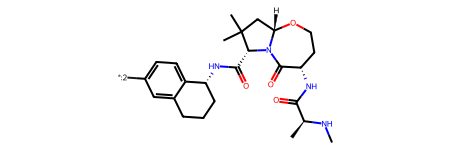

CN[C@@H](C)C(=O)N[C@H](C(=O)N1Cc2cc([*:2])ccc2C[C@H]1C(=O)N[C@@H]1CCCc2ccccc21)C(C)(C)C


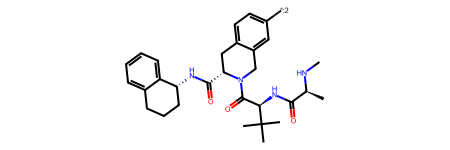

O=c1cc(-c2ccc([*:2])cc2)oc2ccc3ccccc3c12


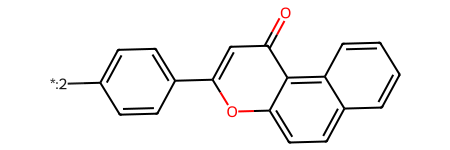

O=c1cc(-c2ccc([*:2])cc2)oc2c1ccc1ccccc12


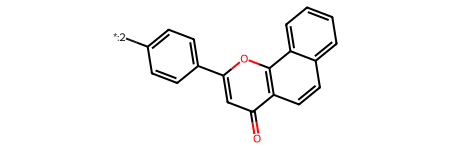

CNC(C)C(=O)NC(C(=O)N1CCCC1c1nc(C(=O)c2ccc(F)cc2)cs1)C1CCN([*:2])CC1


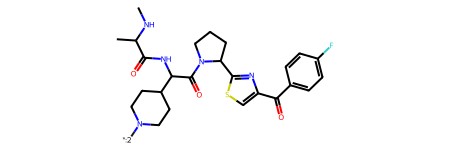

--------------------------------------------------------------------------------
O=C1Oc2cc(O)ccc2CN1c1ccc(CC(=O)[*:1])cc1


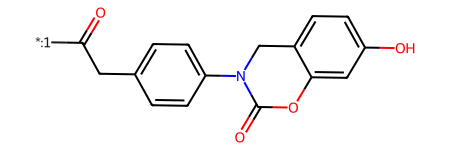

CCCS(=O)(=O)Nc1ccc(F)c(-n2cc(-c3cncnc3)c3nc(N(C)C4CCN([*:1])CC4)ccc32)c1F


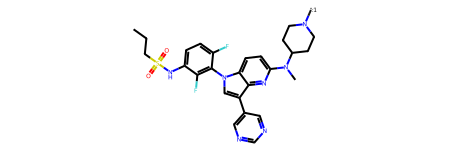

NC(=O)c1c(-c2ccc(Oc3ccc(F)cc3F)cc2)nn([C@H]2CCCN([*:1])C2)c1N


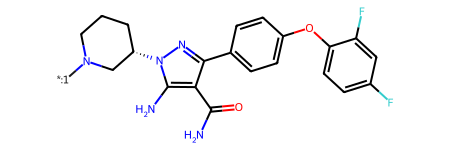

NC(=O)c1c(-c2ccc(Oc3ccc(F)cc3F)cc2)nn([C@H]2CCCN(C(=O)[*:1])C2)c1N


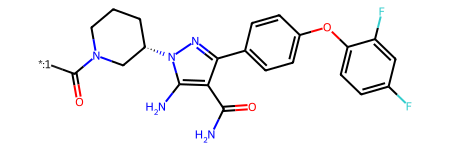

O=C(NC1CCN([*:1])CC1)c1n[nH]cc1NC(=O)c1c(Cl)cccc1Cl


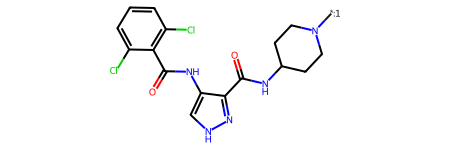

--------------------------------------------------------------------------------
[Cl-].[NH3+]C(CCn1cc(CCCCN[*:1])nn1)C(=O)NCCCC[*:2]


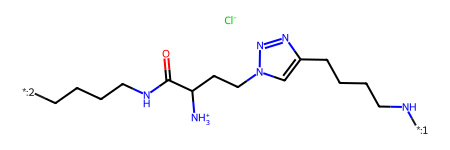

CN(CC=CC(=O)[*:1])CCCCCCCC(=O)[*:2]


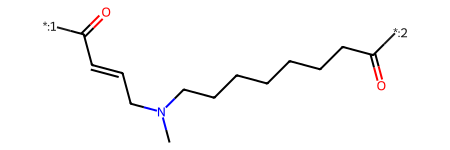

CN(C/C=C/C(=O)[*:1])CCN(C)C(=O)CCCCCC(=O)[*:2]


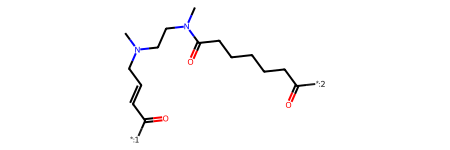

CN(CCCCN[*:2])C[*:1]


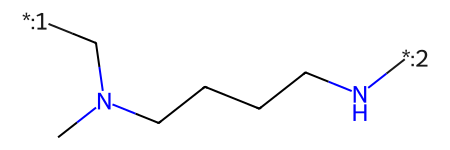

CN(CCCN[*:1])CCCN[*:2]


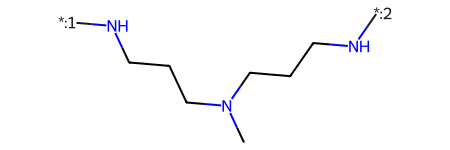

--------------------------------------------------------------------------------


In [21]:
e3_unseen_ligands = [s for c in e3_unseen_clusters for s in e3_cluster2smiles[c]]
wh_unseen_ligands = [s for c in wh_unseen_clusters for s in wh_cluster2smiles[c]]
lk_unseen_ligands = [s for c in lk_unseen_clusters for s in lk_cluster2smiles[c]]

# Sample 10 ligands from each unseen cluster and display their images
e3_unseen_ligands_sample = np.random.choice(e3_unseen_ligands, size=5, replace=False).tolist()
wh_unseen_ligands_sample = np.random.choice(wh_unseen_ligands, size=5, replace=False).tolist()
lk_unseen_ligands_sample = np.random.choice(lk_unseen_ligands, size=5, replace=False).tolist()

for e3 in e3_unseen_ligands_sample:
    print(e3)
    display(Chem.MolFromSmiles(e3))
print('-' * 80)

for wh in wh_unseen_ligands_sample:
    print(wh)
    display(Chem.MolFromSmiles(wh))
print('-' * 80)

for lk in lk_unseen_ligands_sample:
    print(lk)
    display(Chem.MolFromSmiles(lk))
print('-' * 80)

## Datasets Generation

Load the functional groups distributions and the dictionaries mapping FG to substructure SMILES.

- `fg_dist`: for all ligands and for each ligand type (E3 and WH, not the linker), tehre is a dictrionary representing the distribution of functional groups in the curated data. In particular, for each SMARTS, there is a likelihood associated to it, all summing to 1 per dictionary.
- `fg_mappings`: for each ligand type (E3, WH, and linker), there is a dictionary mapping functional groups (as SMARTS) to a list of its corresponding substructures SMILES.

In [22]:
def print_fg_distr(fg_distr):
    for smarts, prob in fg_distr.items():
        print(f'{prob:2.2%} -> {smarts}')
    print('')

def print_fg_mappings(smarts2count):
    # Sort the SMILES by length
    smarts2count = {k: v for k, v in sorted(smarts2count.items(), key=lambda item: len(item[1]), reverse=True)}
    for smarts, smiles in smarts2count.items():
        print(f'[Num. SMILES: {len(smiles):3d}] {smarts} -> {smiles}')
    print('')

# Load from JSON file
filename_distributions = os.path.join(data_dir, 'processed', 'functional_group_distributions.json')
filename_mappings = os.path.join(data_dir, 'processed', 'functional_group_mappings.json')

with open(filename_distributions, 'r') as f:
    fg_distr = json.load(f)

with open(filename_mappings, 'r') as f:
    fg_mappings = json.load(f)

Example of composition:

In [23]:
print(list(fg_distr['fg_distr'].keys())[:5])
print(fg_distr['fg_distr']['[H]-[#7](-[#6])-[#6](-[#6])=[#8]'])
print(list(fg_mappings['poi_fg_2_substr'].keys())[:5])
print(fg_mappings['poi_fg_2_substr']['[H]-[#6](-[H])(-[#6])-[#7](-[#6])-[#6]'][:5])

['[H]-[#7](-[#6])-[#6](-[#6])=[#8]', '[H]-[#7](-[#6])-[#6](:[#6]):[#6]', '[#6]:[#6](:[#6])-[#8]-[#6]', '[#6]-[#6](=[#8])-[#7](-[#6])-[#6]', '[H]-[#6](-[H])(-[#6])-[#7](-[#6])-[#6]']
0.3541446208112875
['[#6]-[#6](=[#8])-[#7](-[#6])-[#6]', '[H]-[#6](-[H])(-[#6])-[#7](-[#6])-[#6]', '[H]-[#7](-[#6])-[#6](-[#7])=[#8]', '[#6]-[#7](-[#6])-[#6](-[#7])=[#16]', '[H]-[#6](-[H])(-[#6])-[#6](-[H])(-[H])-[#7]']
['CN(C)C(=O)c1cc2cnc(Nc3ccc(N4CCN([*:1])CC4)cn3)nc2n1C1CCCC1', 'C[C@@]1(C[*:1])CCC(c2ccc(Cl)cc2)=C(CN2CCN(c3ccc(C(=O)NS(=O)(=O)c4ccc(N[C@H](CCN5CCOCC5)CSc5ccccc5)c(S(=O)(=O)C(F)(F)F)c4)cc3)CC2)C1', 'Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)nn2C1CCN([*:1])CC1', 'NC(=O)CC[C@H](NC(=O)[C@@H]1CC[C@@H]2CCN([*:1])C[C@H](NC(=O)c3cc4cc(C(F)(F)P(=O)(O)O)ccc4[nH]3)C(=O)N21)C(=O)NC(c1ccccc1)c1ccccc1', 'COc1ccc(Cl)c(S(=O)(=O)Nc2ccc(-c3nc(OCC4CN([*:1])CCO4)c4cn[nH]c4n3)cc2)c1']


The validation/test data will be generated using the "unseen" functional groups and a small percentage of the "seen" functional groups.

In [24]:
e3_unseen_ligands = [s for c in e3_unseen_clusters for s in e3_cluster2smiles[c]]
wh_unseen_ligands = [s for c in wh_unseen_clusters for s in wh_cluster2smiles[c]]
lk_unseen_ligands = [s for c in lk_unseen_clusters for s in lk_cluster2smiles[c]]

e3_seen_ligands = [s for c in e3_seen_clusters for s in e3_cluster2smiles[c]]
wh_seen_ligands = [s for c in wh_seen_clusters for s in wh_cluster2smiles[c]]
lk_seen_ligands = [s for c in lk_seen_clusters for s in lk_cluster2smiles[c]]

# Check that they are not intersecting
assert len(set(e3_unseen_ligands).intersection(set(e3_seen_ligands))) == 0
assert len(set(wh_unseen_ligands).intersection(set(wh_seen_ligands))) == 0
assert len(set(lk_unseen_ligands).intersection(set(lk_seen_ligands))) == 0

The `generate_protacs` function expects a mapping from functional groups to lists of ligands SMILES, together with a distribution of functional groups, which we won't alter.

Regarding the mappings, we will remove the seen/unseen ligands from the lists of ligands, so that the generated PROTACs will have a different distribution of ligands.

Here is a sketch of the algorithm:

---

```python
# Train generation
train_data = generate_protacs(e3_fg_map_seen, wh_fg_map_seen, lk_fg_map_seen) # ~1M samples

# Val generation
e3_fg_map_unseen = remove_seen_from(e3)
e3_unseen = generate_protacs(e3_fg_map_unseen, wh_fg_map_seen, lk_fg_map_seen) # 5% of 10K

wh_fg_map_unseen = remove_seen_from(wh)
wh_unseen = generate_protacs(e3_fg_map_seen, wh_fg_map_unseen, lk_fg_map_seen) # 5% of 10K

lk_fg_map_unseen = remove_seen_from(lk)
lk_unseen = generate_protacs(e3_fg_map_seen, wh_fg_map_seen, lk_fg_map_unseen) # 5% of 10K

val_seen_data = generate_protacs(e3_fg_map_seen, wh_fg_map_seen, lk_fg_map_seen) # 75% of 10K
val_data = concat([e3_unseen, wh_unseen, lk_unseen, val_seen_data]) # ~10K samples
```

---

In [25]:
# Isolate the poi and e3 functional groups distributions
seen_e3_fg_2_substr = fg_mappings['e3_fg_2_substr'].copy()
seen_poi_fg_2_substr = fg_mappings['poi_fg_2_substr'].copy()
seen_substr_fg_2_linker = fg_mappings['substr_fg_2_linker'].copy()

# For each SMILES in the FG->List[SMILES] dictionary, keep only the ones that are in the "unseen" clusters
for fg, smiles in seen_e3_fg_2_substr.items():
    seen_e3_fg_2_substr[fg] = [s for s in smiles if s in e3_seen_ligands]

for fg, smiles in seen_poi_fg_2_substr.items():
    seen_poi_fg_2_substr[fg] = [s for s in smiles if s in wh_seen_ligands]

for fg, smiles in seen_substr_fg_2_linker.items():
    seen_substr_fg_2_linker[fg] = [s for s in smiles if s in lk_seen_ligands]

# Isolate the poi and e3 functional groups distributions
unseen_e3_fg_2_substr = fg_mappings['e3_fg_2_substr'].copy()
unseen_poi_fg_2_substr = fg_mappings['poi_fg_2_substr'].copy()
unseen_substr_fg_2_linker = fg_mappings['substr_fg_2_linker'].copy()

# For each SMILES in the FG->List[SMILES] dictionary, keep only the ones that are in the "unseen" clusters
for fg, smiles in unseen_e3_fg_2_substr.items():
    unseen_e3_fg_2_substr[fg] = [s for s in smiles if s in e3_unseen_ligands]

for fg, smiles in unseen_poi_fg_2_substr.items():
    unseen_poi_fg_2_substr[fg] = [s for s in smiles if s in wh_unseen_ligands]

for fg, smiles in unseen_substr_fg_2_linker.items():
    unseen_substr_fg_2_linker[fg] = [s for s in smiles if s in lk_unseen_ligands]

In [26]:
e3_fg_2_substr = fg_mappings['e3_fg_2_substr']
poi_fg_2_substr = fg_mappings['poi_fg_2_substr']
substr_fg_2_linker = fg_mappings['substr_fg_2_linker']

for ligand_name, orig_fg_map, seen_fg_map, unseen_fg_map in zip(['E3', 'POI', 'Linker'], [e3_fg_2_substr, poi_fg_2_substr, substr_fg_2_linker], [seen_e3_fg_2_substr, seen_poi_fg_2_substr, seen_substr_fg_2_linker], [unseen_e3_fg_2_substr, unseen_poi_fg_2_substr, unseen_substr_fg_2_linker]):
    # print(f'{ligand_name} - FG distributions:')
    # print('-' * 80)
    for fg in seen_fg_map.keys():
        orig_len = len(orig_fg_map[fg])
        seen_len = len(seen_fg_map[fg])
        unseen_len = len(unseen_fg_map[fg])
        assert orig_len == seen_len + unseen_len
        # print(f'orig/seen/unseen: {orig_len:4d} | {seen_len:3d} | {unseen_len:3d} - {fg}')
    # print('-' * 80)

In [27]:
from protac_splitter.data.generation import generate_protacs

train_size = 2_000_000
test_size = 15_000
batch_size = 1000
max_workers = 10
cover_all_smiles = True

if os.path.exists(os.path.join(data_dir, 'generated')) is False:
    os.makedirs(os.path.join(data_dir, 'generated'))

if os.path.exists(os.path.join(data_dir, 'generated', 'generated_train_protacs.csv')):
    train_df = pd.read_csv(os.path.join(data_dir, 'generated', 'generated_train_protacs.csv'))
else:
    train_df = generate_protacs(
        poi_fg_distr=fg_distr['poi_fg_distr'],
        e3_fg_distr=fg_distr['e3_fg_distr'],
        poi_fg_2_substr=seen_poi_fg_2_substr,
        e3_fg_2_substr=seen_e3_fg_2_substr,
        substr_fg_2_linker=seen_substr_fg_2_linker,
        num_samples=train_size,
        random_state=42,
        original_df=df_with_functional_groups,
        max_workers=max_workers,
        batch_size=batch_size,
        filename_generated_df=os.path.join(data_dir, 'generated', 'generated_train_protacs.csv'),
        cover_all_smiles=cover_all_smiles,
    )

avoid_df = pd.concat([train_df, df_with_functional_groups]).drop_duplicates(subset='PROTAC SMILES')

assert set(e3_seen_ligands) - set(train_df['E3 Binder SMILES with direction'].unique()) == set()
assert set(wh_seen_ligands) - set(train_df['POI Ligand SMILES with direction'].unique()) == set()
assert set(lk_seen_ligands) - set(train_df['Linker SMILES with direction'].unique()) == set()

if os.path.exists(os.path.join(data_dir, 'generated', 'generated_val_protacs.csv')):
    val_df = pd.read_csv(os.path.join(data_dir, 'generated', 'generated_val_protacs.csv'))
else:
    val_unseen_wh_df = generate_protacs(
        poi_fg_distr=fg_distr['poi_fg_distr'],
        e3_fg_distr=fg_distr['e3_fg_distr'],
        poi_fg_2_substr=unseen_poi_fg_2_substr, # Use unseen SMILES here
        e3_fg_2_substr=seen_e3_fg_2_substr,
        substr_fg_2_linker=seen_substr_fg_2_linker,
        num_samples=int(test_size * 0.05),
        random_state=42 + 1234,
        original_df=avoid_df,
        max_workers=max_workers,
        batch_size=batch_size,
        filename_generated_df=os.path.join(data_dir, 'generated', 'generated_val_unseen_wh_protacs.csv'),
        cover_all_smiles=cover_all_smiles,
    )

    val_unseen_e3_df = generate_protacs(
        poi_fg_distr=fg_distr['poi_fg_distr'],
        e3_fg_distr=fg_distr['e3_fg_distr'],
        poi_fg_2_substr=seen_poi_fg_2_substr,
        e3_fg_2_substr=unseen_e3_fg_2_substr, # Use unseen SMILES here
        substr_fg_2_linker=seen_substr_fg_2_linker,
        num_samples=int(test_size * 0.05),
        random_state=42 + 1234,
        original_df=avoid_df,
        max_workers=max_workers,
        batch_size=batch_size,
        filename_generated_df=os.path.join(data_dir, 'generated', 'generated_val_unseen_e3_protacs.csv'),
        cover_all_smiles=cover_all_smiles,
    )

    val_unseen_lk_df = generate_protacs(
        poi_fg_distr=fg_distr['poi_fg_distr'],
        e3_fg_distr=fg_distr['e3_fg_distr'],
        poi_fg_2_substr=seen_poi_fg_2_substr,
        e3_fg_2_substr=seen_e3_fg_2_substr,
        substr_fg_2_linker=unseen_substr_fg_2_linker, # Use unseen SMILES here
        num_samples=int(test_size * 0.05),
        random_state=42 + 1234,
        original_df=avoid_df,
        max_workers=max_workers,
        batch_size=batch_size,
        filename_generated_df=os.path.join(data_dir, 'generated', 'generated_val_unseen_lk_protacs.csv'),
        cover_all_smiles=cover_all_smiles,
    )

    val_seen_df = generate_protacs(
        poi_fg_distr=fg_distr['poi_fg_distr'],
        e3_fg_distr=fg_distr['e3_fg_distr'],
        poi_fg_2_substr=seen_poi_fg_2_substr,
        e3_fg_2_substr=seen_e3_fg_2_substr,
        substr_fg_2_linker=seen_substr_fg_2_linker,
        num_samples=int(test_size * 0.75),
        random_state=42 + 1234,
        original_df=avoid_df,
        max_workers=max_workers,
        batch_size=batch_size,
        filename_generated_df=os.path.join(data_dir, 'generated', 'generated_val_seen_protacs.csv'),
        cover_all_smiles=cover_all_smiles,
    )

    val_df = pd.concat([val_seen_df, val_unseen_wh_df, val_unseen_e3_df, val_unseen_lk_df]).drop_duplicates(subset='PROTAC SMILES')
    val_df.to_csv(os.path.join(data_dir, 'generated', 'generated_val_protacs.csv'), index=False)

avoid_df = pd.concat([avoid_df, val_df]).drop_duplicates(subset='PROTAC SMILES')

if os.path.exists(os.path.join(data_dir, 'generated', 'generated_test_protacs.csv')):
    test_df = pd.read_csv(os.path.join(data_dir, 'generated', 'generated_test_protacs.csv'))
else:
    test_unseen_wh_df = generate_protacs(
        poi_fg_distr=fg_distr['poi_fg_distr'],
        e3_fg_distr=fg_distr['e3_fg_distr'],
        poi_fg_2_substr=unseen_poi_fg_2_substr, # Use unseen SMILES here
        e3_fg_2_substr=seen_e3_fg_2_substr,
        substr_fg_2_linker=seen_substr_fg_2_linker,
        num_samples=int(test_size * 0.05),
        random_state=1234,
        original_df=avoid_df,
        max_workers=max_workers,
        batch_size=batch_size,
        filename_generated_df=os.path.join(data_dir, 'generated', 'generated_test_unseen_wh_protacs.csv'),
        cover_all_smiles=cover_all_smiles,
    )

    test_unseen_e3_df = generate_protacs(
        poi_fg_distr=fg_distr['poi_fg_distr'],
        e3_fg_distr=fg_distr['e3_fg_distr'],
        poi_fg_2_substr=seen_poi_fg_2_substr,
        e3_fg_2_substr=unseen_e3_fg_2_substr, # Use unseen SMILES here
        substr_fg_2_linker=seen_substr_fg_2_linker,
        num_samples=int(test_size * 0.05),
        random_state=1234,
        original_df=avoid_df,
        max_workers=max_workers,
        batch_size=batch_size,
        filename_generated_df=os.path.join(data_dir, 'generated', 'generated_test_unseen_e3_protacs.csv'),
        cover_all_smiles=cover_all_smiles,
    )

    test_unseen_lk_df = generate_protacs(
        poi_fg_distr=fg_distr['poi_fg_distr'],
        e3_fg_distr=fg_distr['e3_fg_distr'],
        poi_fg_2_substr=seen_poi_fg_2_substr,
        e3_fg_2_substr=seen_e3_fg_2_substr,
        substr_fg_2_linker=unseen_substr_fg_2_linker, # Use unseen SMILES here
        num_samples=int(test_size * 0.05),
        random_state=1234,
        original_df=avoid_df,
        max_workers=max_workers,
        batch_size=batch_size,
        filename_generated_df=os.path.join(data_dir, 'generated', 'generated_test_unseen_lk_protacs.csv'),
        cover_all_smiles=cover_all_smiles,
    )

    test_seen_df = generate_protacs(
        poi_fg_distr=fg_distr['poi_fg_distr'],
        e3_fg_distr=fg_distr['e3_fg_distr'],
        poi_fg_2_substr=seen_poi_fg_2_substr,
        e3_fg_2_substr=seen_e3_fg_2_substr,
        substr_fg_2_linker=seen_substr_fg_2_linker,
        num_samples=int(test_size * 0.75),
        random_state=1234,
        original_df=avoid_df,
        max_workers=max_workers,
        batch_size=batch_size,
        filename_generated_df=os.path.join(data_dir, 'generated', 'generated_test_seen_protacs.csv'),
        cover_all_smiles=cover_all_smiles,
    )

    test_df = pd.concat([test_seen_df, test_unseen_wh_df, test_unseen_e3_df, test_unseen_lk_df]).drop_duplicates(subset='PROTAC SMILES')
    test_df.to_csv(os.path.join(data_dir, 'generated', 'generated_test_protacs.csv'), index=False)

# Check that the generated dataframes are not intersecting
assert len(set(val_df['PROTAC SMILES']).intersection(set(test_df['PROTAC SMILES']))) == 0
assert len(set(val_df['PROTAC SMILES']).intersection(set(train_df['PROTAC SMILES']))) == 0
assert len(set(test_df['PROTAC SMILES']).intersection(set(train_df['PROTAC SMILES']))) == 0

In [28]:
# Check that the intersection of E3, WH, and LK between train and val/test is NOT empty.
# NOTE: This will mean that some of them are not shared between the train and val/test sets, which is what we want.
assert len(set(val_df['E3 Binder SMILES with direction']).intersection(set(train_df['E3 Binder SMILES with direction']))) > 0
assert len(set(test_df['E3 Binder SMILES with direction']).intersection(set(train_df['E3 Binder SMILES with direction']))) > 0
assert set(val_df['E3 Binder SMILES with direction']) - set(test_df['E3 Binder SMILES with direction']) == set()

assert len(set(val_df['POI Ligand SMILES with direction']).intersection(set(train_df['POI Ligand SMILES with direction']))) > 0
assert len(set(test_df['POI Ligand SMILES with direction']).intersection(set(train_df['POI Ligand SMILES with direction']))) > 0
assert set(val_df['POI Ligand SMILES with direction']) - set(test_df['POI Ligand SMILES with direction']) == set()

assert len(set(val_df['Linker SMILES with direction']).intersection(set(train_df['Linker SMILES with direction']))) > 0
assert len(set(test_df['Linker SMILES with direction']).intersection(set(train_df['Linker SMILES with direction']))) > 0
assert set(val_df['Linker SMILES with direction']) - set(test_df['Linker SMILES with direction']) == set()

In [29]:
print(f"Number of unseen E3 ligands: {len(e3_unseen_ligands):>4d} ({len(e3_unseen_ligands) / len(e3_list):.2%})")
print(f"Number of unseen WH ligands: {len(wh_unseen_ligands):>4d} ({len(wh_unseen_ligands) / len(wh_list):.2%})")
print(f"Number of unseen LK ligands: {len(lk_unseen_ligands):>4d} ({len(lk_unseen_ligands) / len(lk_list):.2%})")
print('-' * 80)

for ligand in ['E3 Binder SMILES with direction', 'POI Ligand SMILES with direction', 'Linker SMILES with direction']:
    print(f"Train {ligand}: {len(train_df[ligand].unique())}")
    print(f"Val {ligand}: {len(val_df[ligand].unique())}")
    print(f"Test {ligand}: {len(test_df[ligand].unique())}")

    print('-' * 40)
    
    if ligand == 'E3 Binder SMILES with direction':
        all_ligands = e3_list
        unseen_ligands = e3_unseen_ligands
        seen_ligands = e3_seen_ligands
    elif ligand == 'POI Ligand SMILES with direction':
        all_ligands = wh_list
        unseen_ligands = wh_unseen_ligands
        seen_ligands = wh_seen_ligands
    else:
        all_ligands = lk_list
        unseen_ligands = lk_unseen_ligands
        seen_ligands = lk_seen_ligands
    
    train_num_unseen = sum([1 if x in unseen_ligands else 0 for x in train_df[ligand].unique()])
    val_num_unseen = sum([1 if x in unseen_ligands else 0 for x in val_df[ligand].unique()])
    test_num_unseen = sum([1 if x in unseen_ligands else 0 for x in test_df[ligand].unique()])

    train_num_seen = sum([1 if x in seen_ligands else 0 for x in train_df[ligand].unique()])
    val_num_seen = sum([1 if x in seen_ligands else 0 for x in val_df[ligand].unique()])
    test_num_seen = sum([1 if x in seen_ligands else 0 for x in test_df[ligand].unique()])
    
    print(f"Train {ligand} unseen: {train_num_unseen} ({train_num_unseen / len(all_ligands):2.2%})")
    print(f"Val {ligand} unseen: {val_num_unseen} ({val_num_unseen / len(all_ligands):2.2%})")
    print(f"Test {ligand} unseen: {test_num_unseen} ({test_num_unseen / len(all_ligands):2.2%})")
    print('-' * 80)

Number of unseen E3 ligands:   36 (14.23%)
Number of unseen WH ligands:  138 (15.63%)
Number of unseen LK ligands:  300 (15.57%)
--------------------------------------------------------------------------------
Train E3 Binder SMILES with direction: 217
Val E3 Binder SMILES with direction: 253
Test E3 Binder SMILES with direction: 253
----------------------------------------
Train E3 Binder SMILES with direction unseen: 0 (0.00%)
Val E3 Binder SMILES with direction unseen: 36 (14.23%)
Test E3 Binder SMILES with direction unseen: 36 (14.23%)
--------------------------------------------------------------------------------
Train POI Ligand SMILES with direction: 745
Val POI Ligand SMILES with direction: 883
Test POI Ligand SMILES with direction: 883
----------------------------------------
Train POI Ligand SMILES with direction unseen: 0 (0.00%)
Val POI Ligand SMILES with direction unseen: 138 (15.63%)
Test POI Ligand SMILES with direction unseen: 138 (15.63%)
-----------------------------

In [30]:
print(f"Number of training PROTACs: {len(train_df):>,d}")
print(f"Number of validation PROTACs: {len(val_df):>,d}")
print(f"Number of test PROTACs: {len(test_df):>,d}")

Number of training PROTACs: 1,298,401
Number of validation PROTACs: 11,330
Number of test PROTACs: 11,308


## Plotting

In [31]:
from collections import defaultdict

ligands = {
    'train': defaultdict(list),
    'val': defaultdict(list),
    'test': defaultdict(list),
}
for ligand_name in ['PROTAC SMILES', 'E3 Binder SMILES with direction', 'POI Ligand SMILES with direction', 'Linker SMILES with direction']:
    for ligand in train_df[ligand_name].unique():
        ligands['train'][ligand_name].append(ligand)

    for ligand in val_df[ligand_name].unique():
        ligands['val'][ligand_name].append(ligand)

    for ligand in test_df[ligand_name].unique():
        ligands['test'][ligand_name].append(ligand)

In [32]:
morgan_fp_generator = Chem.rdFingerprintGenerator.GetMorganGenerator(
    radius=16,
    fpSize=1024,
    useBondTypes=True,
    includeChirality=True,
)

def bitvect_to_numpy(bitvect):
    return np.frombuffer(bitvect.ToBitString().encode(), 'u1') - ord('0')

ligands_fp = {
    'train': defaultdict(list),
    'val': defaultdict(list),
    'test': defaultdict(list),
}
for split, ligand_dict in ligands.items():
    for ligand_name, ligand_list in ligand_dict.items():
        filename = os.path.join(data_dir, 'generated', f'{split}_{ligand_name.split(" ")[0].lower()}_fp.npy')
        # Load the FP if it exists
        if os.path.exists(filename):
            ligands_fp[split][ligand_name] = np.load(filename)
            continue

        fp_list = morgan_fp_generator.GetFingerprints([Chem.MolFromSmiles(smiles) for smiles in ligand_list], numThreads=8)
        fp_list = [bitvect_to_numpy(fp) for fp in fp_list]
        ligands_fp[split][ligand_name] = fp_list
        
        print(f"Saving {split} {ligand_name} FP to file {filename}")
        np.save(os.path.join(data_dir, 'generated', f'{split}_{ligand_name}_fp.npy'), np.array(fp_list))

Saving train PROTAC SMILES FP to file /Users/ribes/phd/PROTAC-Splitter/notebooks/../data/generated/train_protac_fp.npy
Saving train E3 Binder SMILES with direction FP to file /Users/ribes/phd/PROTAC-Splitter/notebooks/../data/generated/train_e3_fp.npy
Saving train POI Ligand SMILES with direction FP to file /Users/ribes/phd/PROTAC-Splitter/notebooks/../data/generated/train_poi_fp.npy
Saving train Linker SMILES with direction FP to file /Users/ribes/phd/PROTAC-Splitter/notebooks/../data/generated/train_linker_fp.npy
Saving val PROTAC SMILES FP to file /Users/ribes/phd/PROTAC-Splitter/notebooks/../data/generated/val_protac_fp.npy
Saving val E3 Binder SMILES with direction FP to file /Users/ribes/phd/PROTAC-Splitter/notebooks/../data/generated/val_e3_fp.npy
Saving val POI Ligand SMILES with direction FP to file /Users/ribes/phd/PROTAC-Splitter/notebooks/../data/generated/val_poi_fp.npy
Saving val Linker SMILES with direction FP to file /Users/ribes/phd/PROTAC-Splitter/notebooks/../data/ge

### PCA Plotting

In [44]:
from sklearn.decomposition import PCA

ligands_embeddings = {
    'train': defaultdict(list),
    'val': defaultdict(list),
    'test': defaultdict(list),
}
for split, ligand_dict in ligands_fp.items():
    print(f"Processing {split} set...")
    for ligand_name, ligand_fp_list in ligand_dict.items():
        filename = os.path.join(data_dir, 'generated', f'{split}_{ligand_name.split(" ")[0].lower()}_pca.npy')
        # Load the PCA embeddings if it exists
        if os.path.exists(filename):
            ligands_embeddings[split][ligand_name] = np.load(filename)
            continue

        # Run PCA on the fingerprints
        pca = PCA(n_components=2, random_state=42)
        ligands_embeddings[split][ligand_name] = pca.fit_transform(ligand_fp_list)
        
        # Save the PCA embeddings to file
        print(f"Saving {split} {ligand_name} PCA embeddings to file {filename}")
        np.save(filename, ligands_embeddings[split][ligand_name])

Processing train set...
Processing val set...
Processing test set...


### SVD Plotting

In [42]:
from sklearn.decomposition import TruncatedSVD

ligands_embeddings = {
    'train': defaultdict(list),
    'val': defaultdict(list),
    'test': defaultdict(list),
}
for split, ligand_dict in ligands_fp.items():
    print(f"Processing {split} set...")
    for ligand_name, ligand_fp_list in ligand_dict.items():
        filename = os.path.join(data_dir, 'generated', f'{split}_{ligand_name.split(" ")[0].lower()}_svd.npy')
        # Load the SVD embeddings if it exists
        if os.path.exists(filename):
            ligands_embeddings[split][ligand_name] = np.load(filename)
            continue
        
        # Run SVD on the fingerprints
        svd = TruncatedSVD(n_components=2, random_state=42)
        ligands_embeddings[split][ligand_name] = svd.fit_transform(ligand_fp_list)
        
        # Save the SVD embeddings to file
        print(f"Saving {split} {ligand_name} SVD embeddings to file {filename}")
        np.save(filename, ligands_embeddings[split][ligand_name])
        

Processing train set...
Saving train PROTAC SMILES SVD embeddings to file /Users/ribes/phd/PROTAC-Splitter/notebooks/../data/generated/train_protac_svd.npy
Saving train E3 Binder SMILES with direction SVD embeddings to file /Users/ribes/phd/PROTAC-Splitter/notebooks/../data/generated/train_e3_svd.npy
Saving train POI Ligand SMILES with direction SVD embeddings to file /Users/ribes/phd/PROTAC-Splitter/notebooks/../data/generated/train_poi_svd.npy
Saving train Linker SMILES with direction SVD embeddings to file /Users/ribes/phd/PROTAC-Splitter/notebooks/../data/generated/train_linker_svd.npy
Processing val set...
Saving val PROTAC SMILES SVD embeddings to file /Users/ribes/phd/PROTAC-Splitter/notebooks/../data/generated/val_protac_svd.npy
Saving val E3 Binder SMILES with direction SVD embeddings to file /Users/ribes/phd/PROTAC-Splitter/notebooks/../data/generated/val_e3_svd.npy
Saving val POI Ligand SMILES with direction SVD embeddings to file /Users/ribes/phd/PROTAC-Splitter/notebooks/.

### t-SNE Plotting

In [34]:
# Get t-SNE embeddings
from sklearn.manifold import TSNE

train_data_to_plot = 100_000

ligands_embeddings = {
    'train': defaultdict(list),
    'val': defaultdict(list),
    'test': defaultdict(list),
}
for split, ligand_dict in ligands_fp.items():
    print(f"Processing {split} set...")
    for ligand_name, ligand_fp_list in ligand_dict.items():
        filename = os.path.join(data_dir, 'generated', f'{split}_{ligand_name.split(" ")[0].lower()}_tsne.npy')
        # Load the t-SNE embeddings if it exists
        if os.path.exists(filename):
            ligands_embeddings[split][ligand_name] = np.load(filename)
            continue
        
        # Sample train_data_to_plot data points for the train set
        if split == 'train' and ligand_name == 'PROTAC SMILES':
            np.random.seed(42)
            rand_idx = np.random.choice(len(ligand_fp_list), size=train_data_to_plot, replace=False)
            data_to_tsne = np.array(ligand_fp_list)[rand_idx]
        else:
            data_to_tsne = np.array(ligand_fp_list)
        
        # Run t-SNE on the fingerprints
        tsne = TSNE(n_components=2, random_state=42, n_jobs=8)
        ligands_embeddings[split][ligand_name] = tsne.fit_transform(data_to_tsne)
        
        # Save the t-SNE embeddings to file
        print(f"Saving {split} {ligand_name} t-SNE embeddings to file {filename}")
        np.save(filename, ligands_embeddings[split][ligand_name])

Processing train set...
Saving train E3 Binder SMILES with direction t-SNE embeddings to file /Users/ribes/phd/PROTAC-Splitter/notebooks/../data/generated/train_e3_tsne.npy
Saving train POI Ligand SMILES with direction t-SNE embeddings to file /Users/ribes/phd/PROTAC-Splitter/notebooks/../data/generated/train_poi_tsne.npy
Saving train Linker SMILES with direction t-SNE embeddings to file /Users/ribes/phd/PROTAC-Splitter/notebooks/../data/generated/train_linker_tsne.npy
Processing val set...
Saving val PROTAC SMILES t-SNE embeddings to file /Users/ribes/phd/PROTAC-Splitter/notebooks/../data/generated/val_protac_tsne.npy
Saving val E3 Binder SMILES with direction t-SNE embeddings to file /Users/ribes/phd/PROTAC-Splitter/notebooks/../data/generated/val_e3_tsne.npy
Saving val POI Ligand SMILES with direction t-SNE embeddings to file /Users/ribes/phd/PROTAC-Splitter/notebooks/../data/generated/val_poi_tsne.npy
Saving val Linker SMILES with direction t-SNE embeddings to file /Users/ribes/phd

Plotting...


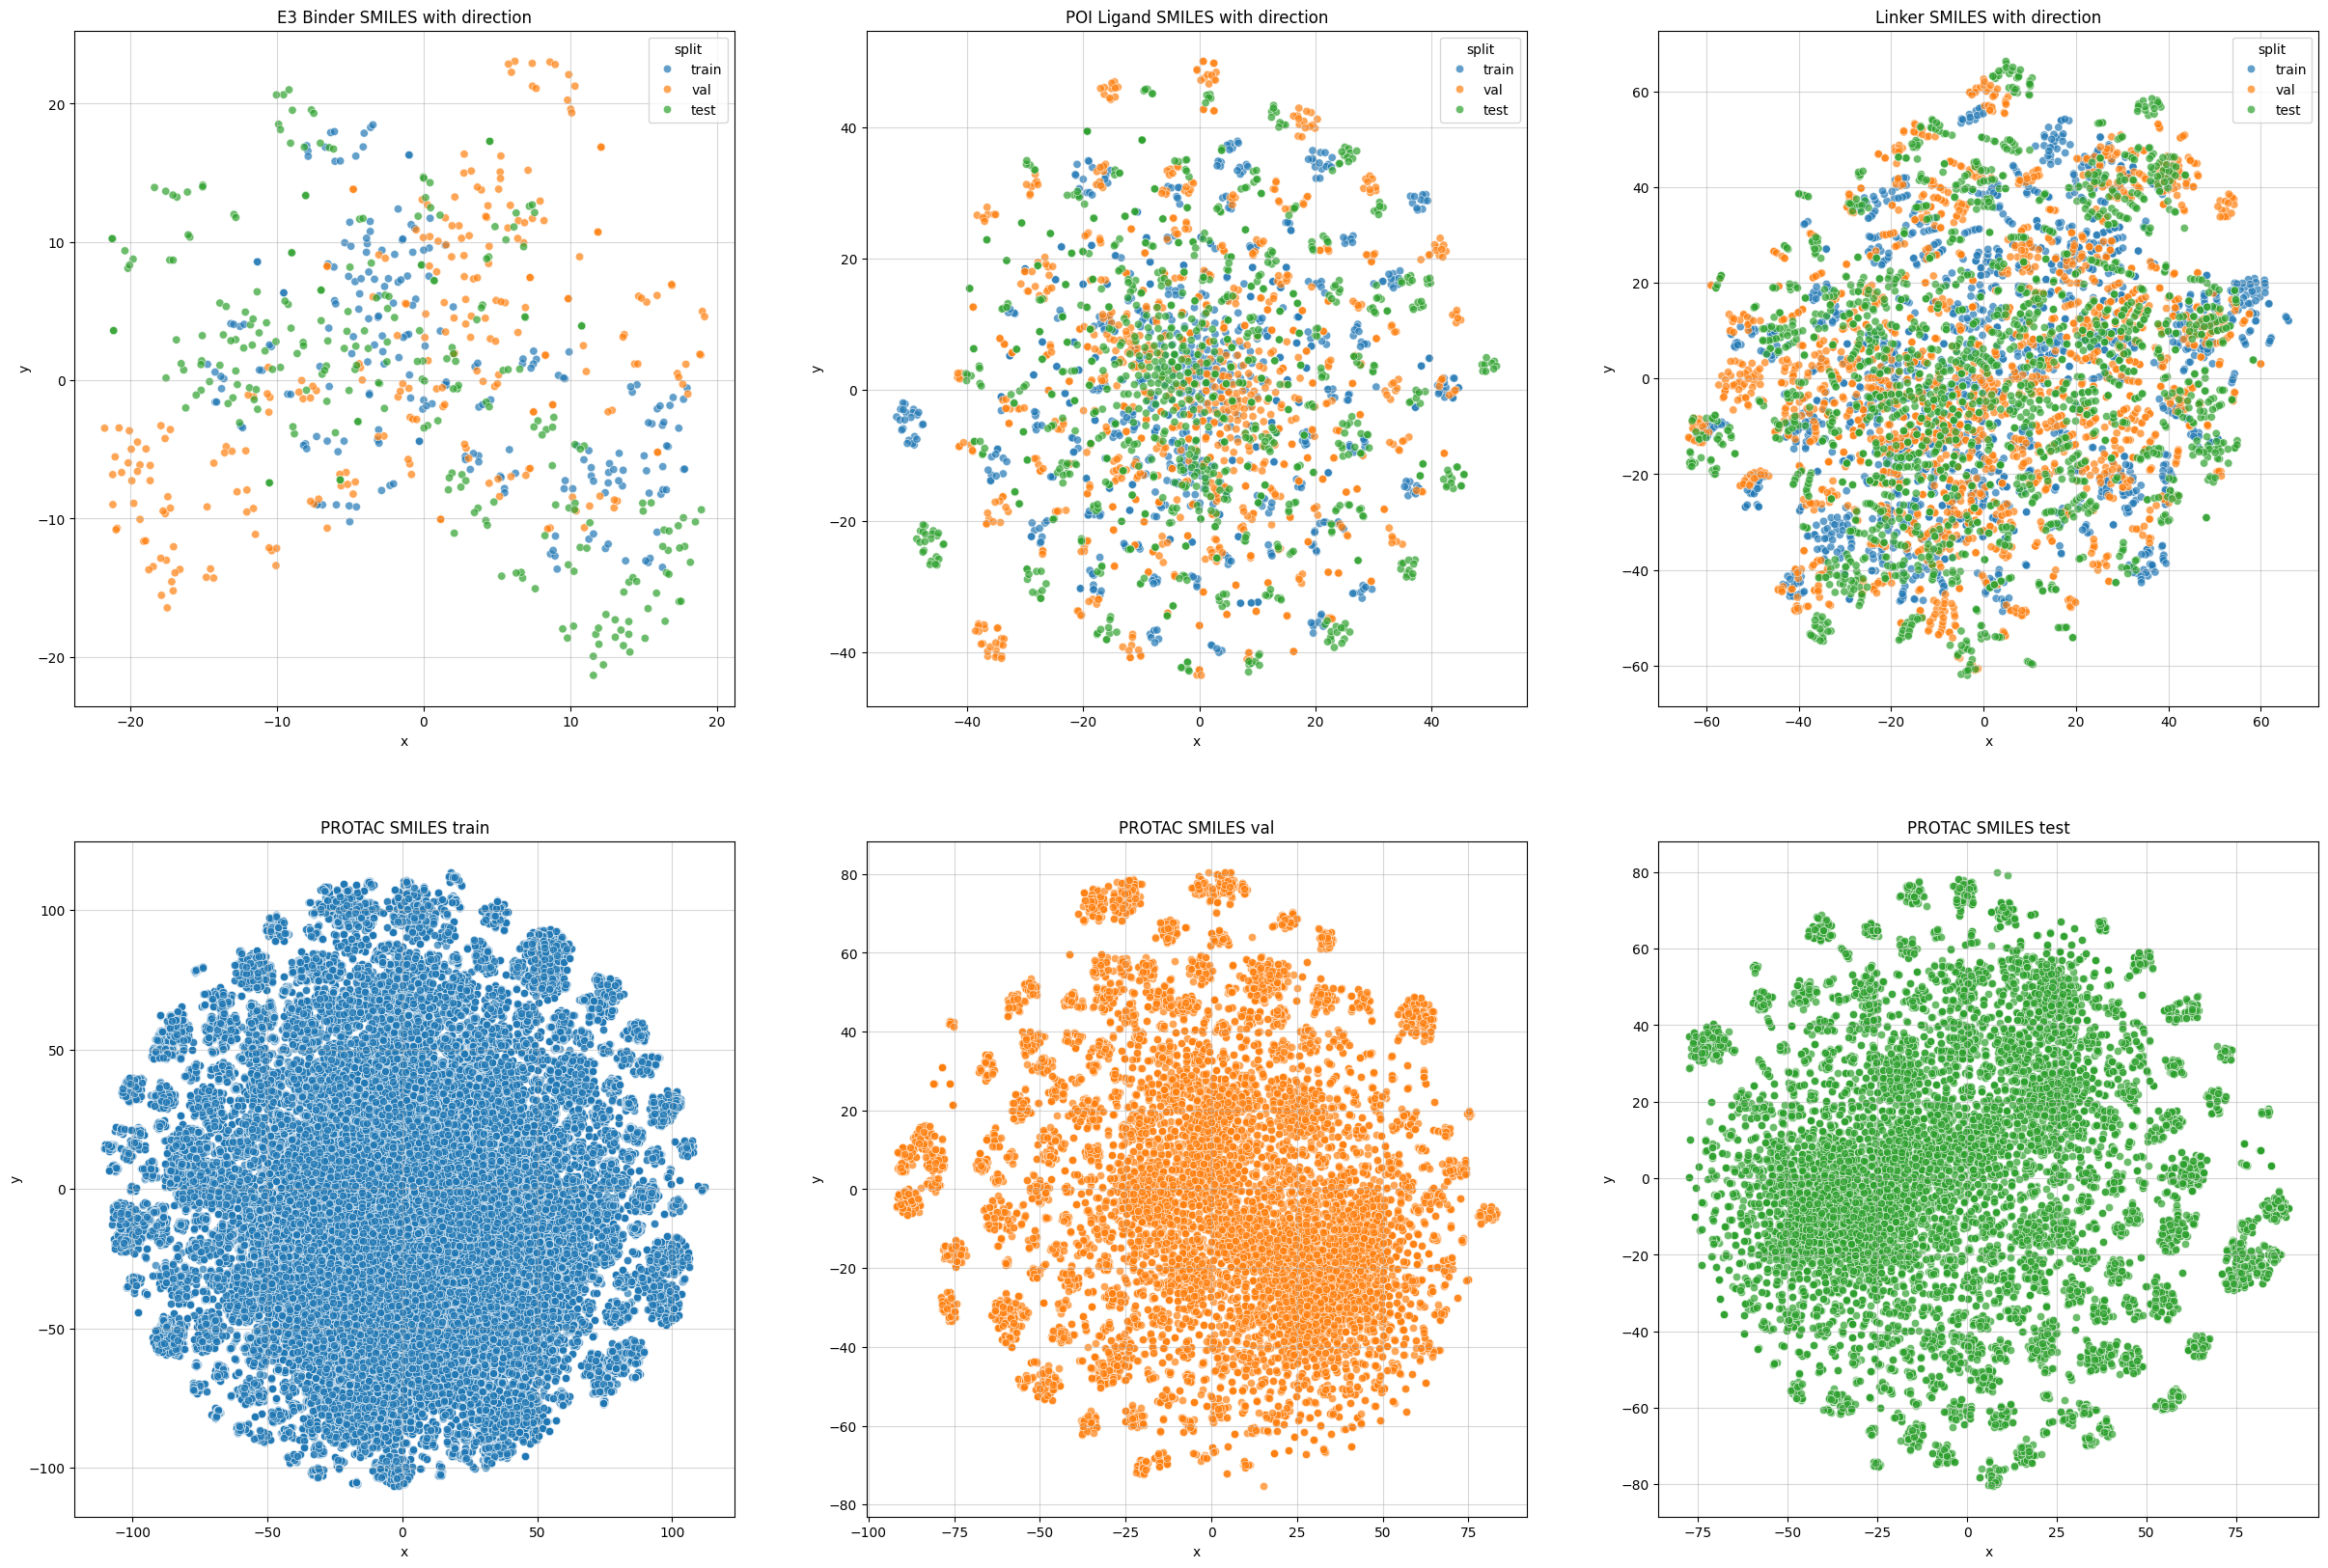

In [48]:
# Create the dataframes to plot based on the PCA and the split assignment, i.e., train, val, test
dfs_to_plot = {}
for ligand_name in ['E3 Binder SMILES with direction', 'POI Ligand SMILES with direction', 'Linker SMILES with direction']:
    dfs_to_plot[ligand_name] = pd.DataFrame({
        'x': np.concatenate([ligands_embeddings['train'][ligand_name][:, 0], ligands_embeddings['val'][ligand_name][:, 0], ligands_embeddings['test'][ligand_name][:, 0]]),
        'y': np.concatenate([ligands_embeddings['train'][ligand_name][:, 1], ligands_embeddings['val'][ligand_name][:, 1], ligands_embeddings['test'][ligand_name][:, 1]]),
        'split': ['train'] * len(ligands_embeddings['train'][ligand_name]) + ['val'] * len(ligands_embeddings['val'][ligand_name]) + ['test'] * len(ligands_embeddings['test'][ligand_name]),
    })

for split in ['train', 'val', 'test']:
    ligand_name = 'PROTAC SMILES'
    dfs_to_plot[f'{ligand_name} {split}'] = pd.DataFrame({
        'x': ligands_embeddings[split][ligand_name][:, 0],
        'y': ligands_embeddings[split][ligand_name][:, 1],
        'split': [split] * len(ligands_embeddings[split][ligand_name]),
    })

print("Plotting...")
# Have the four plots in a single figure, horizontally
fig, axs = plt.subplots(2, 3, figsize=(30, 20))

# for i, (ligand_name, df_to_plot) in enumerate(dfs_to_plot.items()):
#     sns.scatterplot(data=df_to_plot, x='x', y='y', hue='split', legend=True, ax=axs[i // 2, i % 3])
#     axs[i // 2, i % 3].set_title(ligand_name)
#     axs[i // 2, i % 3].grid(alpha=0.5)

for i, (ligand_name, df_to_plot) in enumerate(dfs_to_plot.items()):
    if 'PROTAC SMILES' in ligand_name:
        sns.scatterplot(data=df_to_plot, x='x', y='y', legend=True, ax=axs[i // 3, i % 3], c=f'C{i % 3}', alpha=0.7)
    else:
        sns.scatterplot(data=df_to_plot, x='x', y='y', hue='split', legend=True, ax=axs[i // 3, i % 3], alpha=0.7)
    axs[i // 3, i % 3].set_title(ligand_name)
    axs[i // 3, i % 3].grid(alpha=0.5)

plt.show()

## Cleanup SMILES

Some generated PROTACs include a `.` in the SMILES, which is not allowed. We will remove them.

In [60]:
def remove_smiles_with_fragments(df, col_name):
    tmp =  df[~df[col_name].str.contains(r'\.')]
    # Remove all empty SMILES, like: if smiles in ['[*:1][*:2]', '[*:2][*:1]']
    tmp = tmp[~tmp[col_name].str.contains(r'\[\*\:\d\]\[\*\:\d\]')]
    return tmp

# Loop over the "PROTAC SMILES", if it contains a dot, then remove the entire row from `generated_protacs_df`.
col_names = ['PROTAC SMILES', 'E3 Binder SMILES with direction', 'POI Ligand SMILES with direction', 'Linker SMILES with direction']
tmp = train_df.copy()
for c in col_names:
    tmp = remove_smiles_with_fragments(tmp, c)
print(f'Number of generated PROTACs per train set: {len(train_df):,} (before removing invalid SMILES)')
print(f'Number of generated PROTACs per train set: {len(tmp):,} (after removing invalid SMILES)')
print(f'Number of removed PROTACs: {len(train_df) - len(tmp):,}')
train_df = tmp

tmp = val_df.copy()
for c in col_names:
    tmp = remove_smiles_with_fragments(tmp, c)
print(f'Number of generated PROTACs per val set: {len(val_df):,} (before removing invalid SMILES)')
print(f'Number of generated PROTACs per val set: {len(tmp):,} (after removing invalid SMILES)')
print(f'Number of removed PROTACs: {len(val_df) - len(tmp):,}')
val_df = tmp

tmp = test_df.copy()
for c in col_names:
    tmp = remove_smiles_with_fragments(tmp, c)
print(f'Number of generated PROTACs per test set: {len(test_df):,} (before removing invalid SMILES)')
print(f'Number of generated PROTACs per test set: {len(tmp):,} (after removing invalid SMILES)')
print(f'Number of removed PROTACs: {len(test_df) - len(tmp):,}')
test_df = tmp

Number of generated PROTACs per train set: 1,297,604 (before removing invalid SMILES)
Number of generated PROTACs per train set: 1,297,604 (after removing invalid SMILES)
Number of removed PROTACs: 0
Number of generated PROTACs per val set: 11,315 (before removing invalid SMILES)
Number of generated PROTACs per val set: 11,315 (after removing invalid SMILES)
Number of removed PROTACs: 0
Number of generated PROTACs per test set: 11,296 (before removing invalid SMILES)
Number of generated PROTACs per test set: 11,296 (after removing invalid SMILES)
Number of removed PROTACs: 0


In [61]:
train_df

,PROTAC SMILES,POI Ligand SMILES with direction,Linker SMILES with direction,E3 Binder SMILES with direction,POI Ligand Functional Group,E3 Binder Functional Group
0,CCNC(=O)c1[nH]c2cc(Cl)ccc2c1C(C(=O)NC(C)(C)C)N...,CCNC(=O)c1[nH]c2cc(Cl)ccc2c1C(C(=O)NC(C)(C)C)N...,CN(CCOCCNC(=O)CN[*:2])C(C)(C)C=C(C#N)C(=O)[*:1],O=C1CCC(C2C(=O)c3cccc([*:2])c3C2=O)C(=O)N1,[#6]-[#6](=[#8])-[#7](-[#6])-[#6],[H]-[#7](-[#6])-[#6](:[#6]):[#6]
1,Cc1nn(C)c(COc2ccc(N3CCN(S(=O)(=O)N(C)C)CC3)cc2...,Cc1nn(C)c(COc2ccc(N3CCN(S(=O)(=O)N(C)C)CC3)cc2...,O=C(CCn1cc(CCC[*:1])nn1)[*:2],CC(C)(C)[C@H](NC(=O)C1(C#N)CC1)C(=O)N1C[C@H](O...,[H]-[#6](-[H])(-[#6])-[#7](:[#6]):[#6],[H]-[#7](-[#6])-[#6](-[#6])=[#8]
2,CNCCOc1cc(-c2scnc2C)ccc1CNC(=O)C1CC(O)CN1C(=O)...,Cc1ccc(C(=O)Nc2ccc(CN3CCN(C[*:1])CC3)c(C(F)(F)...,O=C(CCCCCCCCCCC[*:1])[*:2],CNCCOc1cc(-c2scnc2C)ccc1CNC(=O)C1CC(O)CN1C(=O)...,[H]-[#6](-[H])(-[#6])-[#6](-[H])(-[H])-[#7],[H]-[#7](-[#6])-[#6](-[#6])=[#8]
3,CC(C)c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C...,CN1CCN(c2ccc(-c3cc(C(=O)[*:1])ccc3F)cc2NC(=O)c...,O=C(N/N=C/c1ccc(OCCOCCOCCOCCOCCOCC(=O)[*:2])cc...,CC(C)c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C...,[H]-[#7](-[#6])-[#6](-[#6])=[#8],[H]-[#7](-[#6])-[#6](-[#6])=[#8]
4,CNC(C)C(=O)NC(C(=O)N1CCCC1c1nc(C(=O)c2cccc(OCC...,C[C@@H]1OCC2(CCN(c3cnc(Sc4cccc(N[*:1])c4Cl)c(N...,O=C(CO[*:2])[*:1],CNC(C)C(=O)NC(C(=O)N1CCCC1c1nc(C(=O)c2cccc([*:...,[H]-[#7](-[#6])-[#6](-[#6])=[#8],[#6]:[#6](:[#6])-[#8]-[#6]
...,...,...,...,...,...,...
1298396,Nc1ncnc2c1c(-c1ccc(-c3ccccc3)cc1)nn2C1CCCN(C(=...,Nc1ncnc2c1c(-c1ccc(-c3ccccc3)cc1)nn2C1CCCN(C(=...,O=C(CON=[*:1])NCCOCCOCCOCCO[*:2],O=C1CCC(N2C(=O)c3cccc(OCC(=O)[*:2])c3C2=O)C(=O)N1,NaN,NaN
1298397,CNC(C)C(=O)NC(C(=O)N1CCCC1c1cncc(-n2ccc3c(C(=O...,Nc1ncnc2c1c(-c1ccc(-c3ccccc3)cc1)nn2[C@@H]1CCC...,C(#C[*:1])c1cnn([*:2])c1,CNC(C)C(=O)NC(C(=O)N1CCCC1c1cncc(-n2ccc3c(C(=O...,NaN,NaN
1298398,Cc1ncsc1-c1ccc(CNC(=O)[C@H]2C[C@H](O)CN2C(=O)[...,C[C@H]1CC2(CCN(c3ccc(C(=O)N4CCN(C[*:1])CC4)cc3...,O=C(CON=[*:1])NCCOCCOCCOC[*:2],Cc1ncsc1-c1ccc(CNC(=O)[C@H]2C[C@H](O)CN2C(=O)[...,NaN,NaN
1298399,CN[C@@H](C)C(=O)N[C@H](C(=O)N1C[C@@H](NNCCOCCN...,CC1CC2(CCN(c3ccc(C(=O)N4CCN(C[*:1])CC4)cc3)CC2...,O=C(NCCOCCN[*:2])c1ccc([*:1])cc1,CN[C@@H](C)C(=O)N[C@H](C(=O)N1C[C@@H](N[*:2])C...,NaN,NaN


## Upload to Hugging Face

In [57]:
from datasets import Dataset

def get_text_labels(x):
    e3_smiles = x['E3 Binder SMILES with direction']
    linker_smiles = x['Linker SMILES with direction']
    poi_smiles = x['POI Ligand SMILES with direction']
    return {
        'text': x['PROTAC SMILES'],
        'labels': '.'.join([e3_smiles, linker_smiles, poi_smiles]),
    }

def get_dataset(df, num_proc=10):
    # Convert the DataFrame to a Hugging Face Dataset
    ds = Dataset.from_pandas(df, preserve_index=False)
    # Map the dataset: create a new column named "labels" by joining the E3, linker, and POI strings
    ds = ds.map(get_text_labels, num_proc=num_proc)
    # Only take the text and labels columns
    ds = ds.select_columns(['text', 'labels'])
    return ds

train_ds = get_dataset(train_df)
val_ds = get_dataset(val_df)
test_ds = get_dataset(test_df)

Map (num_proc=10):   0%|          | 0/1297604 [00:00<?, ? examples/s]

Map (num_proc=10):   0%|          | 0/11315 [00:00<?, ? examples/s]

Map (num_proc=10):   0%|          | 0/11296 [00:00<?, ? examples/s]

In [59]:
for ds in [train_ds, val_ds, test_ds]:
    for i, sample in enumerate(ds):
        print(f"Sample {i + 1}:\n")
        print(f"Text: {sample['text']}")
        print(f"Labels: {sample['labels']}")
        print('-' * 80)
        if i >= 10:
            break

Sample 1:

Text: CCNC(=O)c1[nH]c2cc(Cl)ccc2c1C(C(=O)NC(C)(C)C)N(Cc1cc(F)c(F)c(F)c1)C(=O)C(C#N)=CC(C)(C)N(C)CCOCCNC(=O)CNc1cccc2c1C(=O)C(C1CCC(=O)NC1=O)C2=O
Labels: O=C1CCC(C2C(=O)c3cccc([*:2])c3C2=O)C(=O)N1.CN(CCOCCNC(=O)CN[*:2])C(C)(C)C=C(C#N)C(=O)[*:1].CCNC(=O)c1[nH]c2cc(Cl)ccc2c1C(C(=O)NC(C)(C)C)N(Cc1cc(F)c(F)c(F)c1)[*:1]
--------------------------------------------------------------------------------
Sample 2:

Text: Cc1nn(C)c(COc2ccc(N3CCN(S(=O)(=O)N(C)C)CC3)cc2)c1-c1cccc2c(CCCOc3cccc4ccccc34)c(C(=O)O)n(CCCc3cn(CCC(=O)C(=O)[C@@H]4C[C@@H](O)CN4C(=O)[C@@H](NC(=O)C4(C#N)CC4)C(C)(C)C)nn3)c12
Labels: CC(C)(C)[C@H](NC(=O)C1(C#N)CC1)C(=O)N1C[C@H](O)C[C@H]1C(=O)[*:2].O=C(CCn1cc(CCC[*:1])nn1)[*:2].Cc1nn(C)c(COc2ccc(N3CCN(S(=O)(=O)N(C)C)CC3)cc2)c1-c1cccc2c(CCCOc3cccc4ccccc34)c(C(=O)O)n([*:1])c12
--------------------------------------------------------------------------------
Sample 3:

Text: CNCCOc1cc(-c2scnc2C)ccc1CNC(=O)C1CC(O)CN1C(=O)C(NC(=O)CCCCCCCCCCCCN1CCN(Cc2ccc(NC(=O)c3ccc(C)c(C#Cc4

In [62]:
mapped_protacs_df = pd.read_csv(os.path.join(data_dir, 'processed', 'mapped_protacs_with_manually_mapped.csv')).reset_index(drop=True)
print(f'Number of mapped PROTACs: {len(mapped_protacs_df):,}')

# Remove all entries with empty linker, i.e., [*:1][*:2] or [*:2][*:1]
mapped_protacs_df = mapped_protacs_df[~mapped_protacs_df['Linker SMILES with direction'].str.contains(r'\[\*\:1\]\[\*\:2\]|\[\*\:2\]\[\*\:1\]')]

# Double check if there are any empty linkers
for smi in mapped_protacs_df['Linker SMILES with direction']:
    if smi in ['[*:1][*:2]', '[*:2][*:1]']:
        print(smi)

print(f'Number of mapped PROTACs: {len(mapped_protacs_df):,} (after removing empty linkers)')

# Load the mapped PROTACs DataFrame into a Hugging Face Dataset
held_out_ds = get_dataset(mapped_protacs_df)
held_out_ds

Number of mapped PROTACs: 5,679
Number of mapped PROTACs: 5,670 (after removing empty linkers)


Map (num_proc=10):   0%|          | 0/5670 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'labels'],
    num_rows: 5670
})

In [63]:
from datasets import DatasetDict

# Combine the training and testing datasets
protac_splitter_ds = DatasetDict({
    'train': train_ds,
    'validation': val_ds,
    'test': test_ds,
    'held_out': held_out_ds,
})

for i, x, in enumerate(protac_splitter_ds['train']):
    if i >= 5:
        break
    print(x)

{'text': 'CCNC(=O)c1[nH]c2cc(Cl)ccc2c1C(C(=O)NC(C)(C)C)N(Cc1cc(F)c(F)c(F)c1)C(=O)C(C#N)=CC(C)(C)N(C)CCOCCNC(=O)CNc1cccc2c1C(=O)C(C1CCC(=O)NC1=O)C2=O', 'labels': 'O=C1CCC(C2C(=O)c3cccc([*:2])c3C2=O)C(=O)N1.CN(CCOCCNC(=O)CN[*:2])C(C)(C)C=C(C#N)C(=O)[*:1].CCNC(=O)c1[nH]c2cc(Cl)ccc2c1C(C(=O)NC(C)(C)C)N(Cc1cc(F)c(F)c(F)c1)[*:1]'}
{'text': 'Cc1nn(C)c(COc2ccc(N3CCN(S(=O)(=O)N(C)C)CC3)cc2)c1-c1cccc2c(CCCOc3cccc4ccccc34)c(C(=O)O)n(CCCc3cn(CCC(=O)C(=O)[C@@H]4C[C@@H](O)CN4C(=O)[C@@H](NC(=O)C4(C#N)CC4)C(C)(C)C)nn3)c12', 'labels': 'CC(C)(C)[C@H](NC(=O)C1(C#N)CC1)C(=O)N1C[C@H](O)C[C@H]1C(=O)[*:2].O=C(CCn1cc(CCC[*:1])nn1)[*:2].Cc1nn(C)c(COc2ccc(N3CCN(S(=O)(=O)N(C)C)CC3)cc2)c1-c1cccc2c(CCCOc3cccc4ccccc34)c(C(=O)O)n([*:1])c12'}
{'text': 'CNCCOc1cc(-c2scnc2C)ccc1CNC(=O)C1CC(O)CN1C(=O)C(NC(=O)CCCCCCCCCCCCN1CCN(Cc2ccc(NC(=O)c3ccc(C)c(C#Cc4cnc5cccnn45)c3)cc2C(F)(F)F)CC1)C(C)(C)C', 'labels': 'CNCCOc1cc(-c2scnc2C)ccc1CNC(=O)C1CC(O)CN1C(=O)C(N[*:2])C(C)(C)C.O=C(CCCCCCCCCCC[*:1])[*:2].Cc1ccc(C(=O)Nc2ccc(CN3CCN

In [64]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('seyonec/ChemBERTa-zinc-base-v1')

In [69]:
# Use the map and filter functions to count how many entries in the protac_splitter_ds will be over the tokenizer.model_max_length
# This is to check if there are any entries that are too long for the tokenizer to handle
for split, ds in protac_splitter_ds.items():
    tmp = ds.map(lambda x: tokenizer(x['text'] + '.' + x['labels'], truncation=False), num_proc=10)
    tmp = tmp.filter(lambda x: len(x['input_ids']) > tokenizer.model_max_length, num_proc=10)
    num_over_max_length = tmp.num_rows
    print(f'Number of entries in {split} that are over the tokenizer.model_max_length: {num_over_max_length}')

Map (num_proc=10):   0%|          | 0/1297604 [00:00<?, ? examples/s]

Filter (num_proc=10):   0%|          | 0/1297604 [00:00<?, ? examples/s]

Number of entries in train that are over the tokenizer.model_max_length: 0


Map (num_proc=10):   0%|          | 0/11315 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (533 > 512). Running this sequence through the model will result in indexing errors


...

Filter (num_proc=10):   0%|          | 0/11296 [00:00<?, ? examples/s]

Number of entries in test that are over the tokenizer.model_max_length: 3


Map (num_proc=10):   0%|          | 0/5670 [00:00<?, ? examples/s]

Filter (num_proc=10):   0%|          | 0/5670 [00:00<?, ? examples/s]

Number of entries in held_out that are over the tokenizer.model_max_length: 0


In [77]:
import huggingface_hub as hf_hub

hf_hub.login()

In [ ]:
# Upload the dataset to the Hugging Face Hub as "standard" configuration
protac_splitter_ds.push_to_hub(
    'ailab-bio/PROTAC-Splitter-Dataset',
    config_name='clustered',
    private=True,
)

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/1298 [00:00<?, ?ba/s]

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/12 [00:00<?, ?ba/s]

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/12 [00:00<?, ?ba/s]

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/6 [00:00<?, ?ba/s]

README.md:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/datasets/ailab-bio/PROTAC-Splitter-Dataset/commit/3d93e50cb5f7a33e50c23b37992026d06a7a0f80', commit_message='Upload dataset', commit_description='', oid='3d93e50cb5f7a33e50c23b37992026d06a7a0f80', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/ailab-bio/PROTAC-Splitter-Dataset', endpoint='https://huggingface.co', repo_type='dataset', repo_id='ailab-bio/PROTAC-Splitter-Dataset'), pr_revision=None, pr_num=None)

### Functional Groups Distribution

In [53]:
from protac_splitter.data.generation import get_functional_group_at_attachment
from tqdm import tqdm

In [32]:
train_df['Notes'] = train_df['E3 Binder Functional Group'].apply(lambda x: f'(ligands_uniformly_sampled={pd.isnull(x)})')
val_df['Notes'] = val_df['E3 Binder Functional Group'].apply(lambda x: f'(ligands_uniformly_sampled={pd.isnull(x)})')
test_df['Notes'] = test_df['E3 Binder Functional Group'].apply(lambda x: f'(ligands_uniformly_sampled={pd.isnull(x)})')

In [ ]:
def get_fg_at_attachment(row, ligand_name: str):
    fg = row[f'{ligand_name} Functional Group']
    if not pd.isnull(fg):
        return fg
    return get_functional_group_at_attachment(
        Chem.MolFromSmiles(row['PROTAC SMILES']),
        Chem.MolFromSmiles(row[f'{ligand_name} SMILES with direction']),
        Chem.MolFromSmiles(row['Linker SMILES with direction']),
        timeout=1,
    )

tqdm.pandas(desc="E3 Binder Train")
train_df['E3 Binder Functional Group'] = train_df.progress_apply(lambda row: get_fg_at_attachment(row, 'E3 Binder'), axis=1)
tqdm.pandas(desc="POI Ligand Train")
train_df['POI Ligand Functional Group'] = train_df.progress_apply(lambda row: get_fg_at_attachment(row, 'POI Ligand'), axis=1)

tqdm.pandas(desc="E3 Binder Val")
val_df['E3 Binder Functional Group'] = val_df.progress_apply(lambda row: get_fg_at_attachment(row, 'E3 Binder'), axis=1)
tqdm.pandas(desc="POI Ligand Val")
val_df['POI Ligand Functional Group'] = val_df.progress_apply(lambda row: get_fg_at_attachment(row, 'POI Ligand'), axis=1)

tqdm.pandas(desc="E3 Binder Test")
test_df['E3 Binder Functional Group'] = test_df.progress_apply(lambda row: get_fg_at_attachment(row, 'E3 Binder'), axis=1)
tqdm.pandas(desc="POI Ligand Test")
test_df['POI Ligand Functional Group'] = test_df.progress_apply(lambda row: get_fg_at_attachment(row, 'POI Ligand'), axis=1)

In [40]:
# Get the combined distribution of functional groups in both POI and E3 Binder Functional Group columns
train_fg_distr = pd.concat([
    train_df['POI Ligand Functional Group'],
    train_df['E3 Binder Functional Group']]).value_counts(normalize=True).to_dict()

val_fg_distr = pd.concat([
    val_df['POI Ligand Functional Group'],
    val_df['E3 Binder Functional Group']]).value_counts(normalize=True).to_dict()

test_fg_distr = pd.concat([
    test_df['POI Ligand Functional Group'],
    test_df['E3 Binder Functional Group']]).value_counts(normalize=True).to_dict()

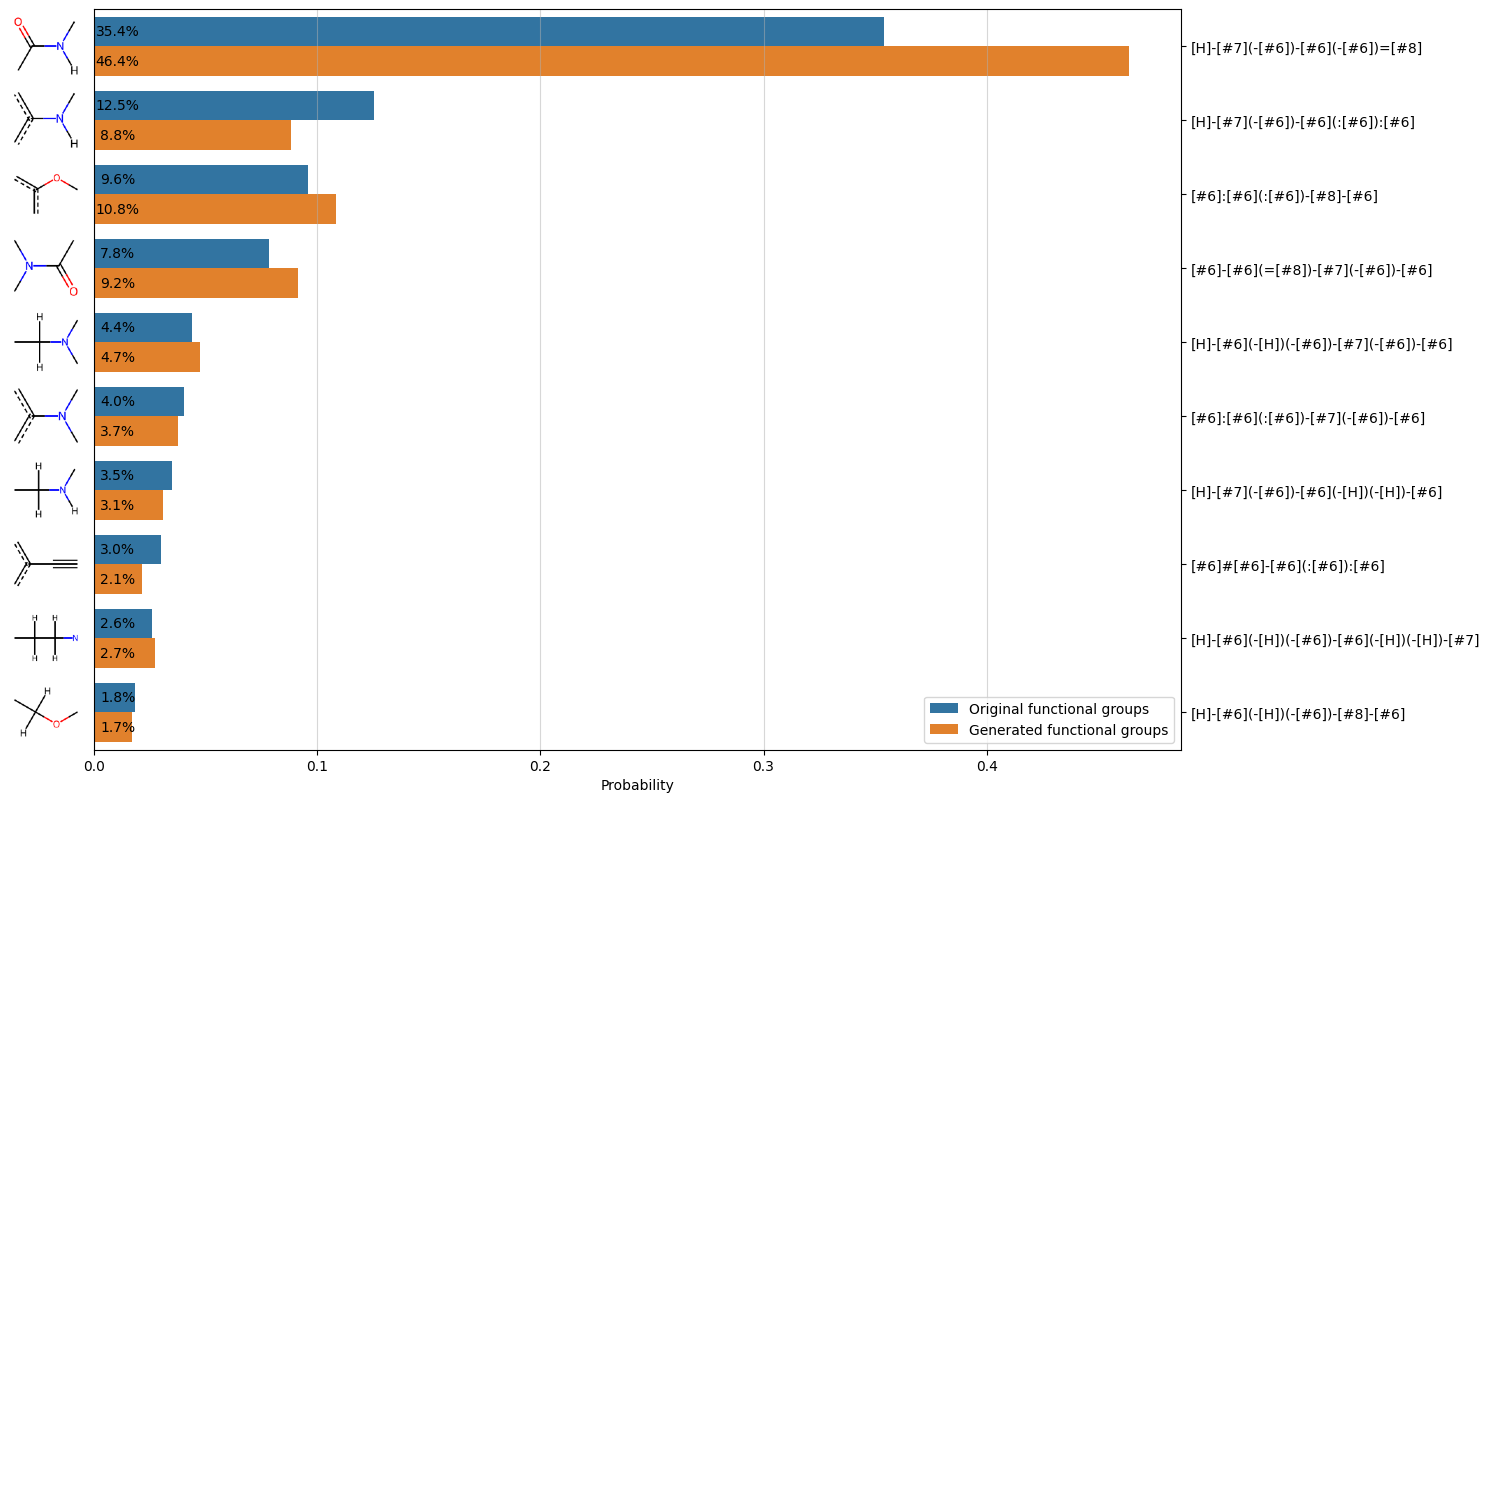

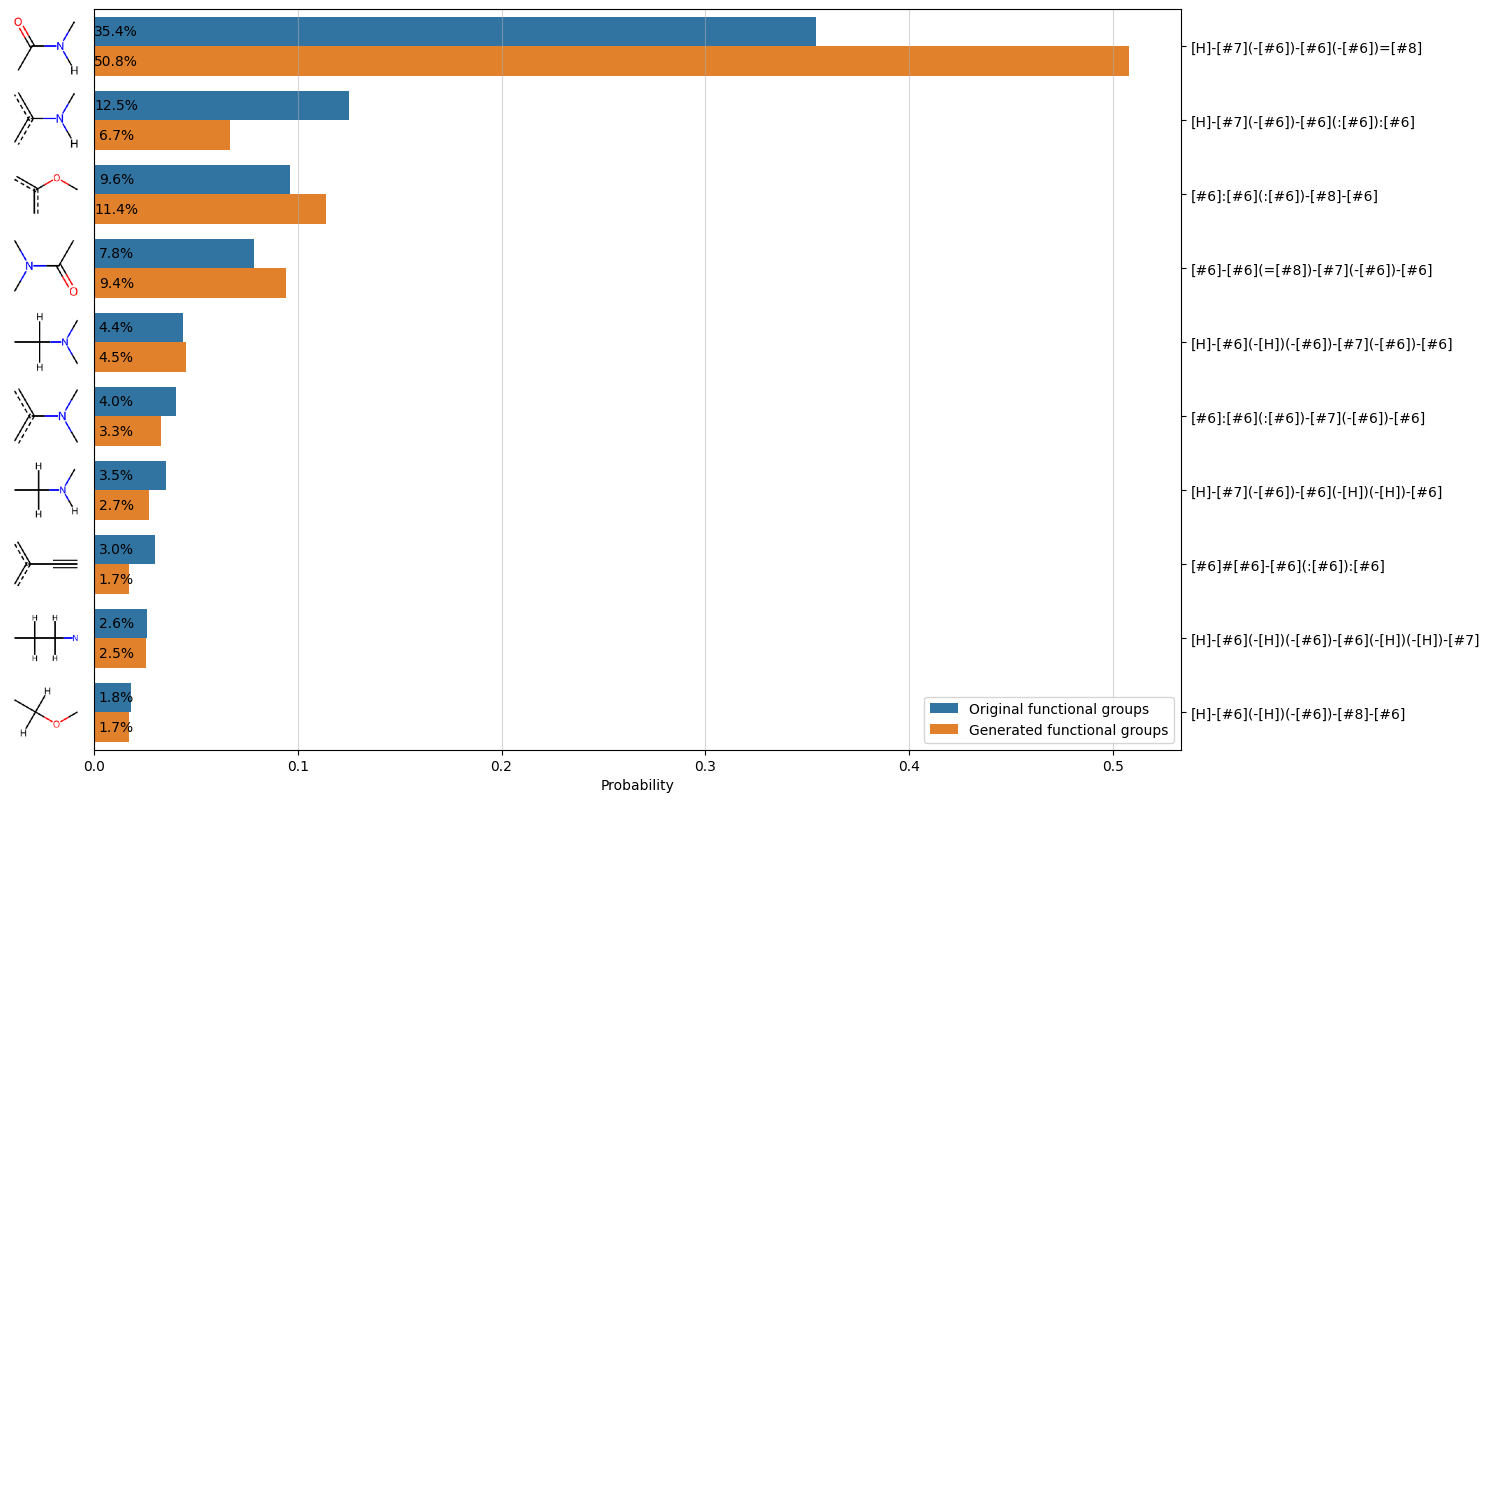

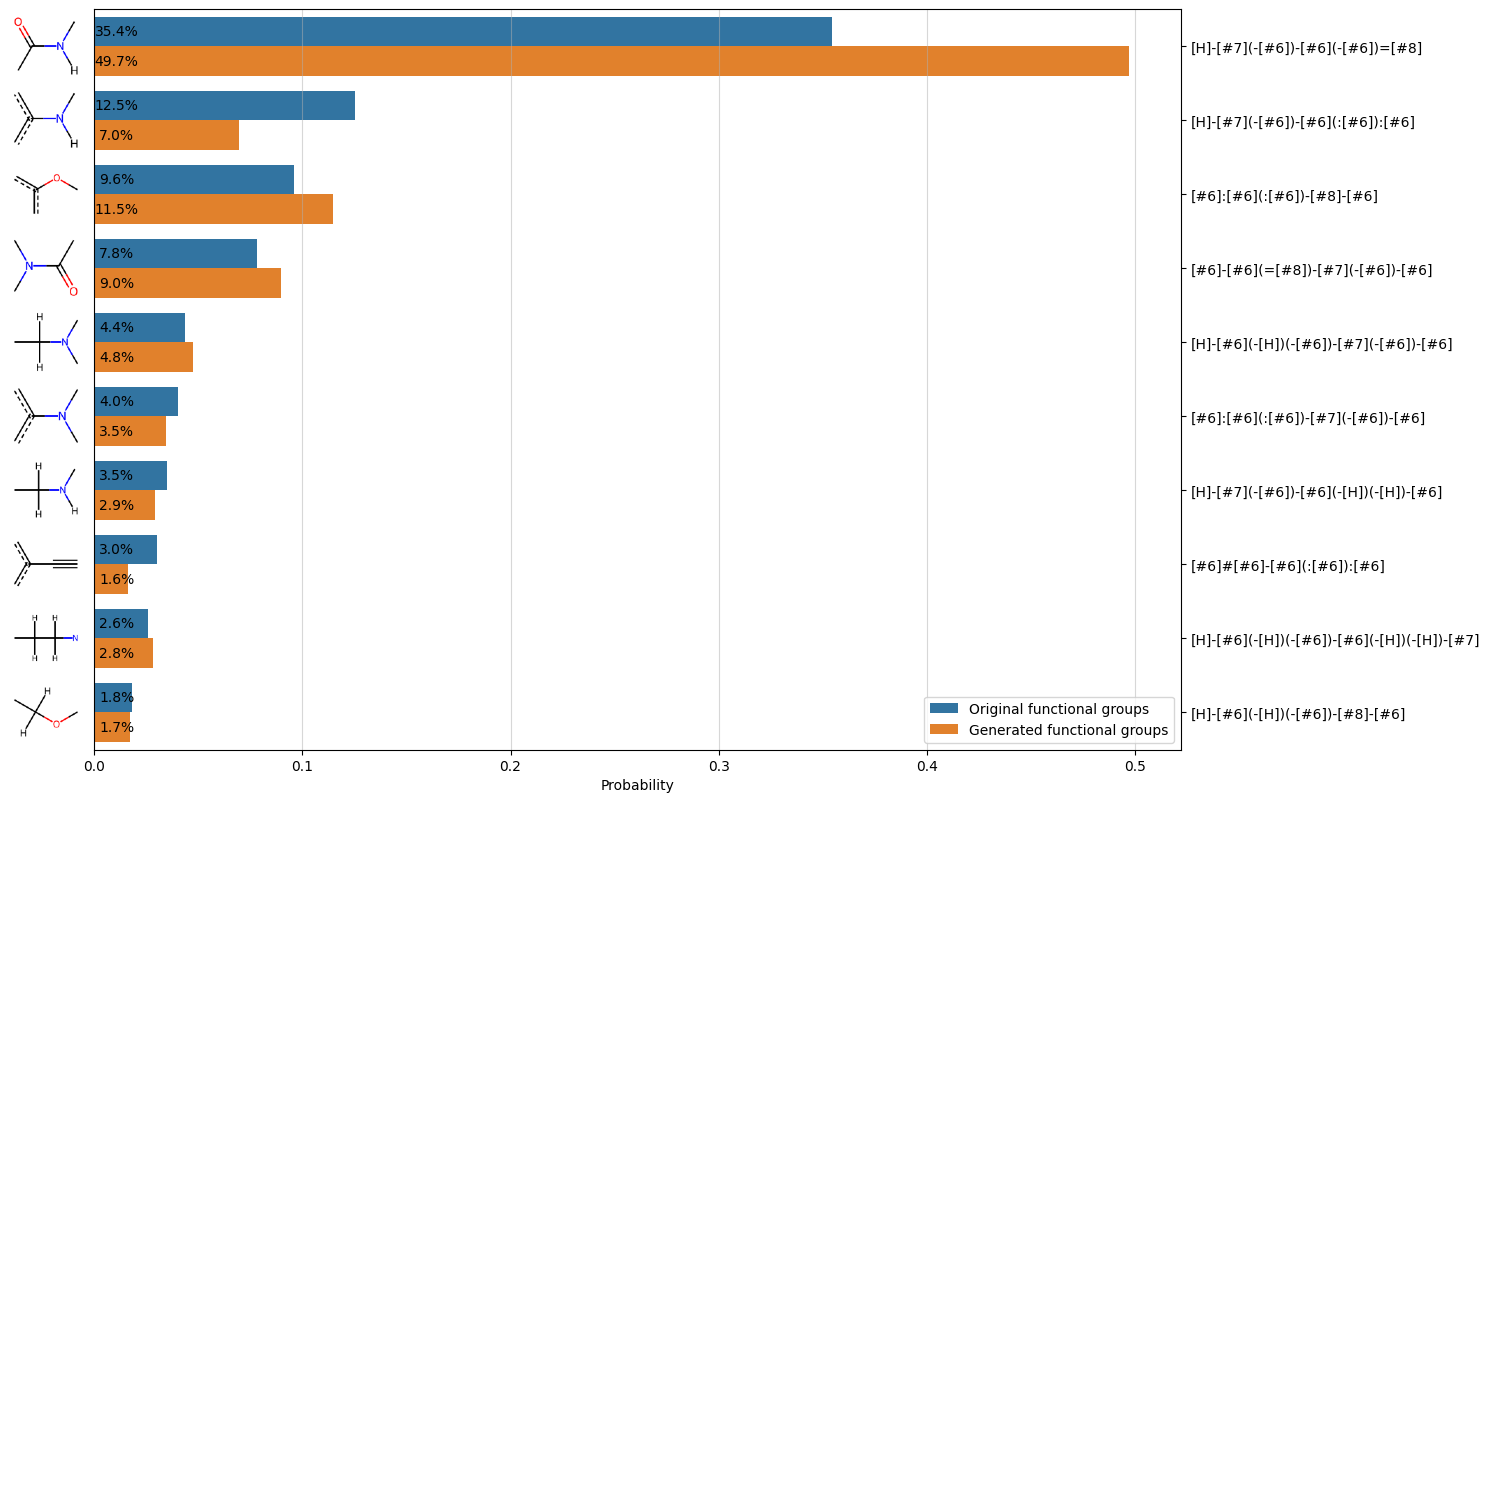

In [42]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import seaborn as sns

filename_distributions = os.path.join(data_dir, 'processed', 'functional_group_distributions.json')

with open(filename_distributions, 'r') as f:
    fg_distr = json.load(f)['fg_distr']

gen_fg_distr = val_fg_distr.copy()

def plot_fg_distr(fg_distr, gen_fg_distr):
    # Get the top-N functional groups according to their probability
    top_n = 10
    fg_distr = dict(sorted(fg_distr.items(), key=lambda x: x[1], reverse=True)[:top_n])
    gen_fg_distr = dict(sorted(gen_fg_distr.items(), key=lambda x: x[1], reverse=True)[:top_n])

    functional_groups = list(fg_distr.keys()) + list(gen_fg_distr.keys())
    probabilities = list(fg_distr.values()) + list(gen_fg_distr.values())

    def get_mol_img(s):
        mol = Chem.MolFromSmarts(s)
        Chem.SanitizeMol(mol)
        Chem.AddHs(mol)
        return Draw.MolToImage(mol, size=(100, 100))

    df_to_plot = pd.DataFrame({
        'Functional Group': functional_groups,
        'Probability': probabilities,
        'Type': ['Original functional groups'] * len(fg_distr) + ['Generated functional groups'] * len(gen_fg_distr),
        'Image': [get_mol_img(s) for s in functional_groups],
    })

    # Plot setup
    fig, ax = plt.subplots(figsize=(15, 30))

    ax = sns.barplot(y='Functional Group', x='Probability', hue='Type', data=df_to_plot, orient='h', ax=ax)

    # Move the y-labels to the right
    ax.yaxis.tick_right()

    # Generate image for each functional group in the y-axis
    for i, (smarts, prob, img) in enumerate(zip(df_to_plot['Functional Group'], df_to_plot['Probability'], df_to_plot['Image'])):
        # Convert PIL image to a format Matplotlib can handle
        imagebox = OffsetImage(img, zoom=0.5)  # Adjust zoom for appropriate size
        ab = AnnotationBbox(
            imagebox,
            (0, i),  # Place the image at the corresponding bar's y-coordinate
            frameon=False,
            xycoords="data",
            box_alignment=(1.2, 0.5),  # Align image correctly on the left
            pad=0.05,
        )
        ax.add_artist(ab)

    # Add the probabilities as text on the bars
    for p in ax.patches:
        # Handle case when the probability is 0
        prob = p.get_width()
        if prob == 0:
            continue

        # Get the scale of the width
        width_scale = abs(ax.get_xlim()[1] - ax.get_xlim()[0]) / 100
        y = 0.0075 # p.get_x() + p.get_width() + width_scale * 2.5
        x = p.get_y() + p.get_height() / 2

        ax.annotate(f'{p.get_width():>2.1%}', (y, x), ha='center', va='center', xytext=(5, 0), textcoords='offset points')

    # Set axis labels and title
    ax.set_xlabel("Probability")
    ax.set_ylabel("")
    # plt.title("Functional Group Distribution")

    # Place the legend in the bottom-right corner and remove the title
    plt.legend(loc='lower right', title=None)
    plt.grid(axis='x', alpha=0.5)

    # Adjust layout
    plt.tight_layout()
    plt.show()


plot_fg_distr(fg_distr, train_fg_distr)
plot_fg_distr(fg_distr, val_fg_distr)
plot_fg_distr(fg_distr, test_fg_distr)

## Cluster and Isolate Representative Held-Out Samples

We aim to isolate $N$ representative samples from the held-out dataset, so that a potential user can manually label, _i.e._, split, $N$ PROTACs and then finetune the model on those data.

The following code aims at finding those "most representative" samples via clustering.

In [4]:
import os
from typing import List

import pandas as pd
import numpy as np
from tqdm import tqdm
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

In [2]:
data_dir = os.path.join(os.getcwd(), '..', 'data')
filename_held_out_df = os.path.join(data_dir, 'processed', 'mapped_protacs_with_functional_groups.csv')
held_out_df = pd.read_csv(filename_held_out_df)
len(held_out_df)

5670

In [5]:
def get_fp(smiles: str, fp_generator) -> np.ndarray:
    """
    Get the Morgan fingerprint of a molecule from its SMILES representation.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = fp_generator.GetFingerprint(mol)
    return np.array(fp)


# Get the fingerprints:
morgan_fp_generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=16,
    fpSize=1024,
    useBondTypes=True,
    includeChirality=True,
)

fp_dict = {smi: get_fp(smi, morgan_fp_generator) for smi in held_out_df['PROTAC SMILES']}
fp_list = list(fp_dict.values())
fp2smiles = {fp.tobytes(): smi for smi, fp in fp_dict.items() if fp is not None}

In [85]:
num_smiles = held_out_df['PROTAC SMILES'].nunique()
num_fp = len(fp2smiles)
print(f"Number of unique SMILES: {num_smiles:,}")
print(f"Number of unique fingerprints: {num_fp:,}")
# Check if the number of unique fingerprints is equal to the number of unique SMILES
if num_smiles != num_fp:
    print("WARNING. The number of unique fingerprints is not equal to the number of unique SMILES, you may want to adjust how fingerprints are generated.")

Number of unique SMILES: 5,670
Number of unique fingerprints: 5,670


I'm just copy-pasting the code from above here, for not re-running all of it.

In [ ]:
from sklearn.cluster import AgglomerativeClustering, KMeans


def get_umap_clusters_fp(fp_list: List[str], n_clusters: int = 7) -> np.ndarray:
    """
    Cluster a list of SMILES strings using the umap clustering algorithm.
    From Scaffold Splits Overestimate Virtual Screening Performance
    https://arxiv.org/abs/2406.00873

    :param fp_list: List of SMILES strings
    :param n_clusters: The number of clusters to use for clustering
    :return: Array of cluster labels corresponding to each SMILES string in the input list.
    """
    ac = AgglomerativeClustering(n_clusters=n_clusters)
    ac.fit_predict(np.stack(fp_list))
    return ac.labels_


def get_kmeans_clusters_fp(fp_list: List[str], n_clusters: int = 10, return_centroids: bool = False) -> np.ndarray:
    """
    Cluster a list of SMILES strings using the KMeans clustering algorithm.

    :param fp_list: List of SMILES strings
    :param n_clusters: The number of clusters to use for clustering
    :return: Array of cluster labels corresponding to each SMILES string in the input list.
    """
    km = KMeans(n_clusters=n_clusters, n_init='auto', random_state=42, max_iter=1000)
    if return_centroids:
        km.fit(np.stack(fp_list))
        return km.labels_, km.cluster_centers_
    return km.fit_predict(np.stack(fp_list))

In [70]:
import seaborn as sns
from matplotlib import pyplot as plt
from scipy.stats import skew
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

def evaluate_clusters(X, clusters):
    """Compute clustering metrics and assess cluster size distribution."""
    
    unique_clusters = list(set(clusters))
    
    if len(unique_clusters) < 2:  # Avoid single-cluster issues
        return {
            "silhouette": -1,
            "davies_bouldin": float("inf"),
            "calinski_harabasz": -1,
            "avg_cluster_size": len(X),
            "avg_cluster_data_ratio": 1,
            "std_cluster_size": 0,
            "min_cluster_size": len(X),
            "median_cluster_size": len(X),
            "max_cluster_size": len(X),
            "cluster_size_skewness": 0,
            "num_clusters": 1,
        }

    # Compute standard clustering metrics
    silhouette = silhouette_score(X, clusters)
    davies_bouldin = davies_bouldin_score(X, clusters)
    calinski_harabasz = calinski_harabasz_score(X, clusters)

    # Compute cluster size statistics
    cluster_sizes = [len(np.where(clusters == i)[0]) for i in np.unique(clusters)]
    avg_cluster_size = np.mean(cluster_sizes)
    avg_cluster_data_ratio = avg_cluster_size / len(X)
    std_cluster_size = np.std(cluster_sizes)
    median_cluster_size = np.median(cluster_sizes)
    min_cluster_size = np.min(cluster_sizes)
    max_cluster_size = np.max(cluster_sizes)
    cluster_size_skewness = skew(cluster_sizes, nan_policy="omit")  # Indicates imbalance in cluster sizes

    return {
        "silhouette": silhouette,
        "davies_bouldin": davies_bouldin,
        "calinski_harabasz": calinski_harabasz,
        "avg_cluster_size": avg_cluster_size,
        "avg_cluster_data_ratio": avg_cluster_data_ratio,
        "std_cluster_size": std_cluster_size,
        "min_cluster_size": min_cluster_size,
        "median_cluster_size": median_cluster_size,
        "max_cluster_size": max_cluster_size,
        "cluster_size_skewness": cluster_size_skewness,
        "num_clusters": len(unique_clusters),
    }

In [ ]:
centroids_dict = {}
clusters_dict = {}
metrics_df = []
for n_clusters in tqdm([10, 25, 50], desc="Clustering and evaluating"):
    clusters, centroids = get_kmeans_clusters_fp(fp_list, n_clusters=n_clusters, return_centroids=True)
    metrics = evaluate_clusters(fp_list, clusters)
    clusters_dict[f'kmeans_n{n_clusters}'] = clusters.copy()
    centroids_dict[n_clusters] = centroids.copy()

    metrics['num_clusters'] = n_clusters
    metrics['cluster_algorithm'] = 'kmeans'
    metrics_df.append(metrics.copy())
    
    clusters = get_umap_clusters_fp(fp_list, n_clusters=n_clusters)
    metrics = evaluate_clusters(fp_list, clusters)
    clusters_dict[f'umap_n{n_clusters}'] = clusters.copy()

    metrics['num_clusters'] = n_clusters
    metrics['cluster_algorithm'] = 'umap'
    metrics_df.append(metrics.copy())

metrics_df = pd.DataFrame(metrics_df)
metrics_df

Clustering and evaluating: 100%|██████████| 3/3 [00:18<00:00,  6.16s/it]


,silhouette,davies_bouldin,calinski_harabasz,avg_cluster_size,avg_cluster_data_ratio,std_cluster_size,min_cluster_size,median_cluster_size,max_cluster_size,cluster_size_skewness,num_clusters,cluster_algorithm
0,0.031627,4.689311,81.426882,567.0,0.10,313.495136,90,577.5,1199,0.337363,10,kmeans
1,0.015386,5.406901,60.586154,567.0,0.10,408.354258,132,506.0,1518,1.011948,10,umap
2,0.032346,4.394529,48.935977,226.8,0.04,141.453879,34,220.0,536,0.486273,25,kmeans
3,0.021279,4.512318,38.522437,226.8,0.04,213.230955,48,148.0,884,1.996347,25,umap
4,0.042684,3.737129,31.767157,113.4,0.02,110.662550,4,77.5,512,1.904517,50,kmeans
5,0.026695,3.963949,27.755764,113.4,0.02,98.410365,26,78.0,476,1.974431,50,umap


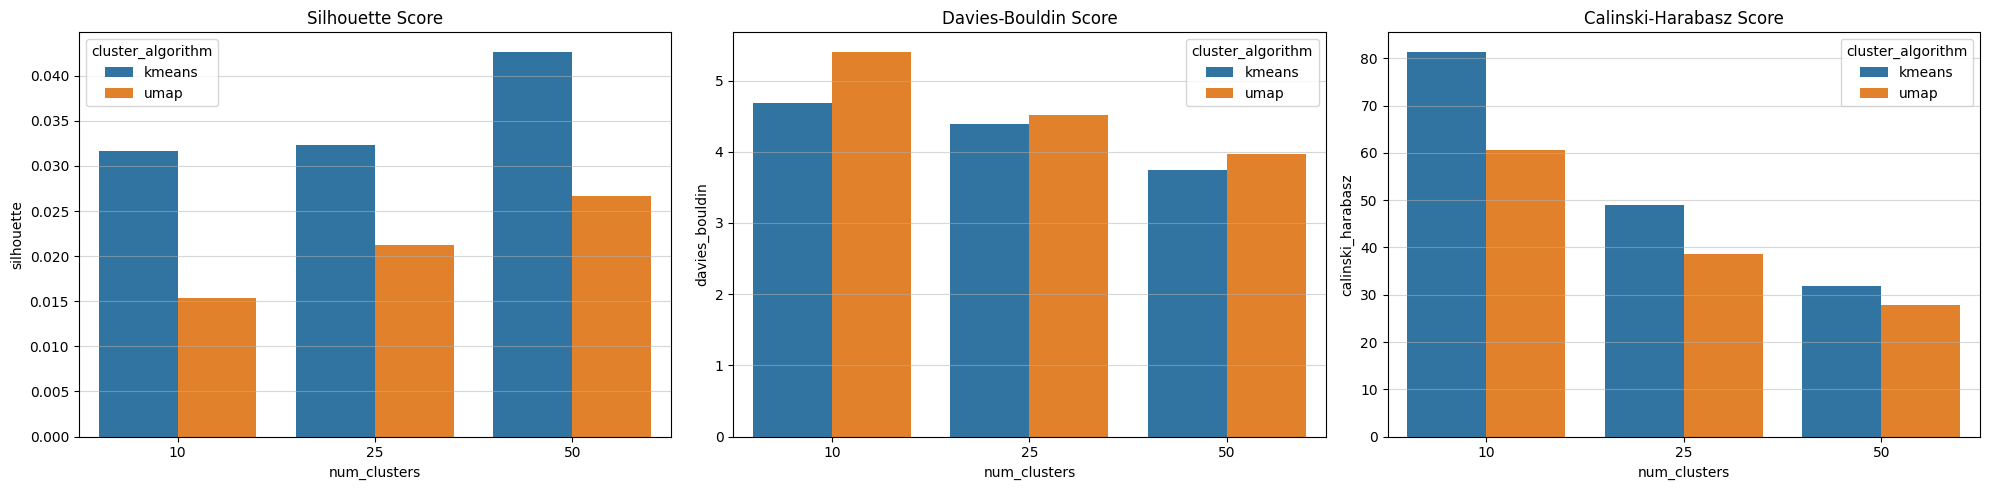

In [72]:
# Bar-plot silhouette score, Davies-Bouldin score, and Calinski-Harabasz score, hue by the clustering algorithm
fig, axs = plt.subplots(1, 3, figsize=(20, 5))
sns.barplot(data=metrics_df, x='num_clusters', y='silhouette', hue='cluster_algorithm', ax=axs[0])
axs[0].set_title('Silhouette Score')
sns.barplot(data=metrics_df, x='num_clusters', y='davies_bouldin', hue='cluster_algorithm', ax=axs[1])
axs[1].set_title('Davies-Bouldin Score')
sns.barplot(data=metrics_df, x='num_clusters', y='calinski_harabasz', hue='cluster_algorithm', ax=axs[2])
axs[2].set_title('Calinski-Harabasz Score')
plt.tight_layout()
for ax in axs:
    ax.grid(axis='y', alpha=0.5)
plt.show()

In [ ]:
from datasets import load_dataset

def get_text_labels(x):
    e3_smiles = x['E3 Binder SMILES with direction']
    linker_smiles = x['Linker SMILES with direction']
    poi_smiles = x['POI Ligand SMILES with direction']
    return {
        'text': x['PROTAC SMILES'],
        'labels': '.'.join([e3_smiles, linker_smiles, poi_smiles]),
    }

def process_dataframe(df):
    processed = df.apply(get_text_labels, axis=1, result_type='expand')
    return processed[['text', 'labels']]


# Create a finetuning dataset, with one different configuration for each cluster
ds_root = os.path.join(data_dir, 'finetuning_dataset')
os.makedirs(ds_root, exist_ok=True)

for n_clusters, centroids in centroids_dict.items():
    print('-' * 80)
    print(f'Number of clusters: {n_clusters}')
    print('-' * 80)
    # Get the cluster labels for the centroids
    clusters = np.array(clusters_dict[f'kmeans_n{n_clusters}'])
    finetune_samples = []
    for label, centroid in enumerate(centroids):
        # Isolate the FP with the same label as the centroid
        fp_cluster = np.array(fp_list)[clusters == label]
        # Get the closest FP for the centroid, use euclidean distance
        distances = np.linalg.norm(fp_cluster - centroid, axis=1)
        closest_fp = np.argmin(distances)
        # To get the SMILES from the FP, use the fp2smiles dictionary
        closest_smiles = fp2smiles[fp_cluster[closest_fp].tobytes()]
        # Print the closest SMILES
        print(f'Closest FP to centroid n.{label}: {closest_smiles}')
        sample = held_out_df.loc[held_out_df['PROTAC SMILES'] == closest_smiles]
        finetune_samples.append(sample)

        # Visualization
        # protac_smiles = sample['PROTAC SMILES'].values[0]
        # e3_smiles = sample['E3 Binder SMILES with direction'].values[0]
        # lk_smiles = sample['Linker SMILES with direction'].values[0]
        # wh_smiles = sample['POI Ligand SMILES with direction'].values[0]
        
        # display(Chem.MolFromSmiles(protac_smiles))
        # display(Chem.MolFromSmiles('.'.join([e3_smiles, lk_smiles, wh_smiles])))
        # print('-' * 80)

    finetune_samples_df = pd.concat(finetune_samples)
    train_df = process_dataframe(finetune_samples_df)

    # Remove the isolated samples from the held-out dataset to get a test set
    test_df = held_out_df[~held_out_df['PROTAC SMILES'].isin(finetune_samples_df['PROTAC SMILES'])].copy()
    test_df = process_dataframe(test_df)

    os.makedirs(os.path.join(ds_root, f'n{n_clusters}'), exist_ok=True)
    train_df.to_csv(os.path.join(ds_root, f'n{n_clusters}', 'train.csv'), index=False)
    test_df.to_csv(os.path.join(ds_root, f'n{n_clusters}', 'test.csv'), index=False)
    print(f'Dataset configuration saved to {os.path.join(ds_root, f"n{n_clusters}")}')

    # Load the dataset to check if it was saved correctly
    ds = load_dataset(ds_root, data_dir=f'n{n_clusters}')
    print(ds)

print('-' * 80)
ds = load_dataset(ds_root, data_dir='n10') # Final check
print(ds['train'][0])

--------------------------------------------------------------------------------
Number of clusters: 10
--------------------------------------------------------------------------------
Closest FP to centroid n.0: Cc1ncsc1-c1ccc(C(C)NC(=O)C2CC(O)CN2C(=O)C(NC(=O)CCCCOc2ccc(-c3csc(N4CCOCC4)n3)c(F)c2)C(C)(C)C)cc1
Closest FP to centroid n.1: O=C1CCC(N2C(=O)c3cccc(NCCOCCNc4cccc5c4C(=O)N(C4CCC(=O)NC4=O)C5=O)c3C2=O)C(=O)N1
Closest FP to centroid n.2: Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@@H](NC(=O)COCCOCCOCCOCC(=O)N[C@H](C(=O)N2C[C@H](O)C[C@H]2C(=O)NCc2ccc(-c3scnc3C)cc2)C(C)(C)C)C(C)(C)C)cc1
Closest FP to centroid n.3: O=C1CCC(N2C(=O)c3cccc(OCc4ccc(C(=O)NO)cc4)c3C2=O)C(=O)N1
Closest FP to centroid n.4: Cc1ncsc1-c1ccc(CNC(=O)C2CC(O)CN2C(=O)C(NC(=O)COCCOCCOCCOCC(=O)NC(C(=O)N2CC(O)CC2C(=O)NCc2ccc(-c3scnc3C)cc2)C(C)(C)C)C(C)(C)C)cc1
Closest FP to centroid n.5: CC1(c2nc3c(C(N)=O)cccc3[nH]2)CCCN1CCOCCOCCOCCOCCNc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
Closest FP to centroid n.6: Nc1ncnc2c1c(-c

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 10
    })
    test: Dataset({
        features: ['text', 'labels'],
        num_rows: 5660
    })
})
--------------------------------------------------------------------------------
Number of clusters: 25
--------------------------------------------------------------------------------
Closest FP to centroid n.0: Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@H](NC(=O)CCCCCCCNC(=O)CC(=O)Nc2cccc(Sc3ncc(N4CCC(C)(N)CC4)nc3N)c2Cl)C(C)(C)C)cc1
Closest FP to centroid n.1: O=C1CCC(N2C(=O)c3cccc(NCCC(=O)N4CCN(c5cccc(-c6cnc7ccc(N8CCC[C@@H]8c8cccc(F)c8)nn67)n5)CC4)c3C2=O)C(=O)N1
Closest FP to centroid n.2: O=C1CCC(N2C(=O)c3cccc(OCCOCCOCCOc4cccc5c4C(=O)N(C4CCC(=O)NC4=O)C5=O)c3C2=O)C(=O)N1
Closest FP to centroid n.3: CC1(c2nc3c(C(N)=O)cccc3[nH]2)CCCN1CCOCCOCCOCCOCCNc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
Closest FP to centroid n.4: Cc1cc(OCCCCC(=O)N[C@H](C(=O)N2C[C@H](O)C[C@H]2C(=O)N[C@@H](C)c2ccc(-c3sc

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 25
    })
    test: Dataset({
        features: ['text', 'labels'],
        num_rows: 5645
    })
})
--------------------------------------------------------------------------------
Number of clusters: 50
--------------------------------------------------------------------------------
Closest FP to centroid n.0: Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)[C@H](NC(=O)CCCCCCCNC(=O)CC(=O)Nc2cccc(Sc3ncc(N4CCC(C)(N)CC4)nc3N)c2Cl)C(C)(C)C)cc1
Closest FP to centroid n.1: O=C1CCC(N2C(=O)c3cccc(NCCC(=O)N4CCN(c5cccc(-c6cnc7ccc(N8CCC[C@@H]8c8cccc(F)c8)nn67)n5)CC4)c3C2=O)C(=O)N1
Closest FP to centroid n.2: O=C1CCC(N2C(=O)c3cccc(OCc4ccc(C(=O)NO)cc4)c3C2=O)C(=O)N1
Closest FP to centroid n.3: CC1(c2nc3c(C(N)=O)cccc3[nH]2)CCCN1CCOCCOCCOCCOCCNc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O
Closest FP to centroid n.4: Cc1cc(OCCCCC(=O)N[C@H](C(=O)N2C[C@H](O)C[C@H]2C(=O)N[C@@H](C)c2ccc(-c3scnc3C)cc2)C(C)(C)C)ccc1-c1c

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 50
    })
    test: Dataset({
        features: ['text', 'labels'],
        num_rows: 5620
    })
})
--------------------------------------------------------------------------------
{'text': 'Cc1ncsc1-c1ccc(C(C)NC(=O)C2CC(O)CN2C(=O)C(NC(=O)CCCCOc2ccc(-c3csc(N4CCOCC4)n3)c(F)c2)C(C)(C)C)cc1', 'labels': 'Cc1ncsc1-c1ccc(C(C)NC(=O)C2CC(O)CN2C(=O)C(N[*:2])C(C)(C)C)cc1.O=C(CCCCO[*:1])[*:2].Fc1cc([*:1])ccc1-c1csc(N2CCOCC2)n1'}


---

send statistics when done with the generation of the synthetic data.

the percentages seen/unseen refer to the ligands SMILES, not the functional groups.

TODO: When sampling the val/test data, make sure to:

- Not sample all unseen ligands, i.e., one out of E3, linker and WH need to be seen.
- Balance sampling seen and unseen ligands after after sampling the functional group. 

TODO: When covering the unseen ligands, is it ok to sample SMILES only from the "leftover" ones? Or shall I sample from all the ligands? Does it make a difference?

- Answer: it is ok to sample from the "leftover" ligands only. It shouldn't make a (significant) difference.